# 240501 Salicylate-Hypochlorite Ammonia Assay(Ammonium-N)
- Date: 5/13/24, experiment and measurement of 240501
- Analysis: Kiseok Lee
- Motivation: ammonia time series dynamics of soils with 3 different pH levels.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('./custom_functions_Ammonia')
import pandas as pd
import numpy as np
import ammonia as am
import bmgdata as bd
import glob
import denitfit as dn
import pickle
import matplotlib.pyplot as plt
import os

# figure size and font size
import matplotlib.pylab as pylab
params = {'legend.fontsize': 'xx-large',
          'figure.figsize': (20, 12),
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
pylab.rcParams.update(params)

## 1. Standard curves of Salicylate-Hypochlorite Ammonia Assay (Using bubble removal using well scan)

In [2]:
newpath = r'./240501_Ammonia/Output'
if not os.path.exists(newpath):
    os.makedirs(newpath)

## 1.1. Standard curves on 240501 (10ul sampling)
standard

./240501_Ammonia/standards_metadata.csv
None
./240501_Ammonia\standard_20240501_Absorbance_KL_Ammonia_SCAN_650.CSV
./240501_Ammonia\standard_20240501_Absorbance_KL_Ammonia_SCAN_900.CSV
returns true for elements more than 1 interquartile ranges above the upper quartile
These wells had NaN values:  []
A01    4.05410
A02    4.13755
A03    4.11350
B01    2.32385
B02    2.35250
B03    2.33935
C01    1.36790
C02    1.38175
C03    1.37785
D01    0.86025
D02    0.85990
D03    0.85715
E01    0.59130
E02    0.61210
E03    0.60125
F01    0.45655
F02    0.46500
F03    0.46205
G01    0.39485
G02    0.40185
G03    0.39620
H01    0.32600
H02    0.32820
H03    0.32640
Name: 650, dtype: float64
returns true for elements more than 1 interquartile ranges above the upper quartile
These wells had NaN values:  []
A01    4.05410
A02    4.13755
A03    4.11350
B01    2.32385
B02    2.35250
B03    2.33935
C01    1.36790
C02    1.38175
C03    1.37785
D01    0.86025
D02    0.85990
D03    0.85715
E01    0.59130
E0

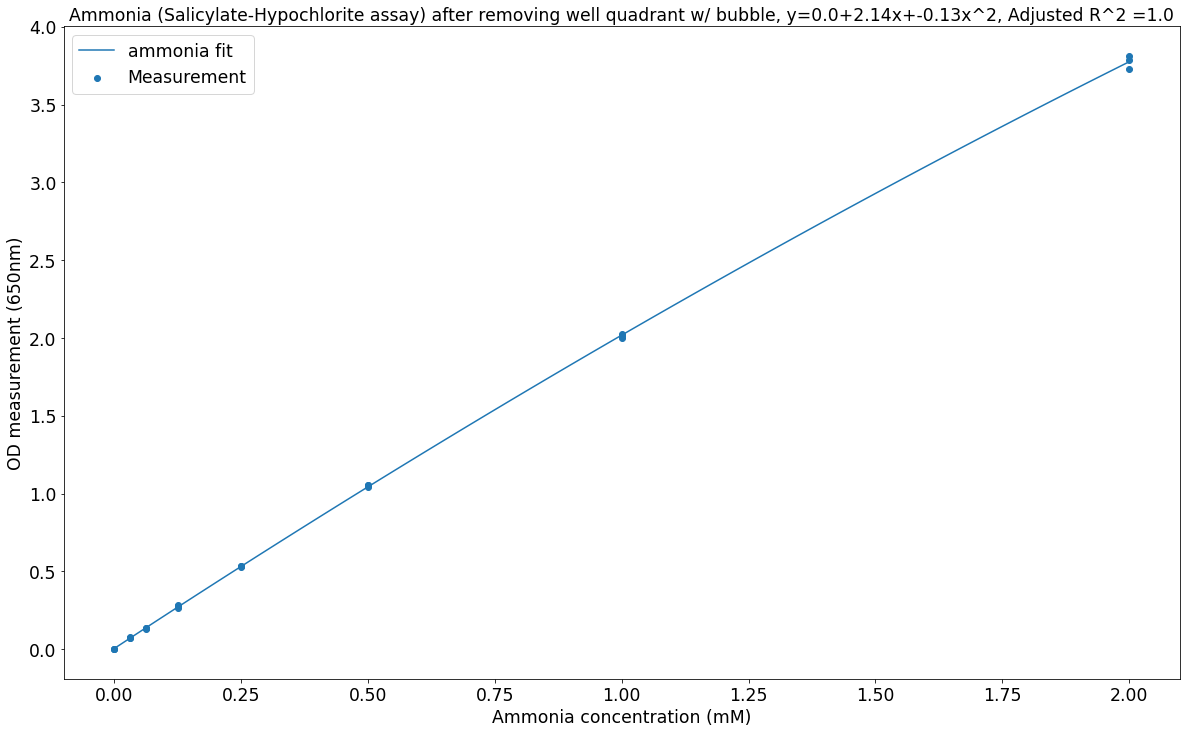

In [3]:
#fit Ammonia assay model using standard curves
std_meta_fn = "./240501_Ammonia/standards_metadata.csv" # since 12C mg/ml and 16 C mg/ml is too high(recognize as bubbles). I'll eliminate those rows.
print(std_meta_fn)
#std_am_fn = None
#std_am_fn = glob.glob("./240501_Ammonia/*KL_Ammonia_no_scan*standard*")[0]
std_am_fn = None
print(std_am_fn)
std_am_absorb_fn = glob.glob("./240501_Ammonia/*standard*Ammonia_SCAN_650*")[0] # I included the standards in plate6 (last plate)
print(std_am_absorb_fn)
std_am_900_fn = glob.glob("./240501_Ammonia/*standard*Ammonia_SCAN_900*")[0]
print(std_am_900_fn)

# plot first
am.plot_ammonia_fit_rm_bubble(meta_fn = std_meta_fn, wavelength="650", data_fn = None, data_absorb_fn = std_am_absorb_fn, data_900_fn = std_am_900_fn)
plt.savefig('./240501_Ammonia/Output/240501_Ammonia_standard_curve_10ul_with_bubble_removal.png')

# fit
fit_list = am.fit_ammonia(meta_fn = std_meta_fn, wavelength="650", data_fn = std_am_fn, data_absorb_fn = std_am_absorb_fn, data_900_fn = std_am_900_fn)
[[ammonia_blank], fit, b_fit] = fit_list 

print("fit: ", fit)
print("b_fit: ", b_fit, "\n")
# here I only have well scan data, so fit = b_fit

## 3.1. Soil7 and Soil10 Measuring ammonia for multiple soils

In [4]:
## generate all sample names
#l_soil = ["AW_plate1_2", "Starke3","Oxbow3","Washington2"]
l_soil = ["Soil7","Soil10"]
l_timepoint = ['T' + str(i) for i in range(0,10) ]

Soil7_T0
./240501_Ammonia/sample_metadata_Soil7_T0.csv
None
./240501_Ammonia\Soil7_T0_20240501_Absorbance_KL_Ammonia_SCAN_650.CSV
./240501_Ammonia\Soil7_T0_20240501_Absorbance_KL_Ammonia_SCAN_900.CSV
Check wellscan for outlier removal in Ammonia
returns true for elements more than 1 interquartile ranges above the upper quartile


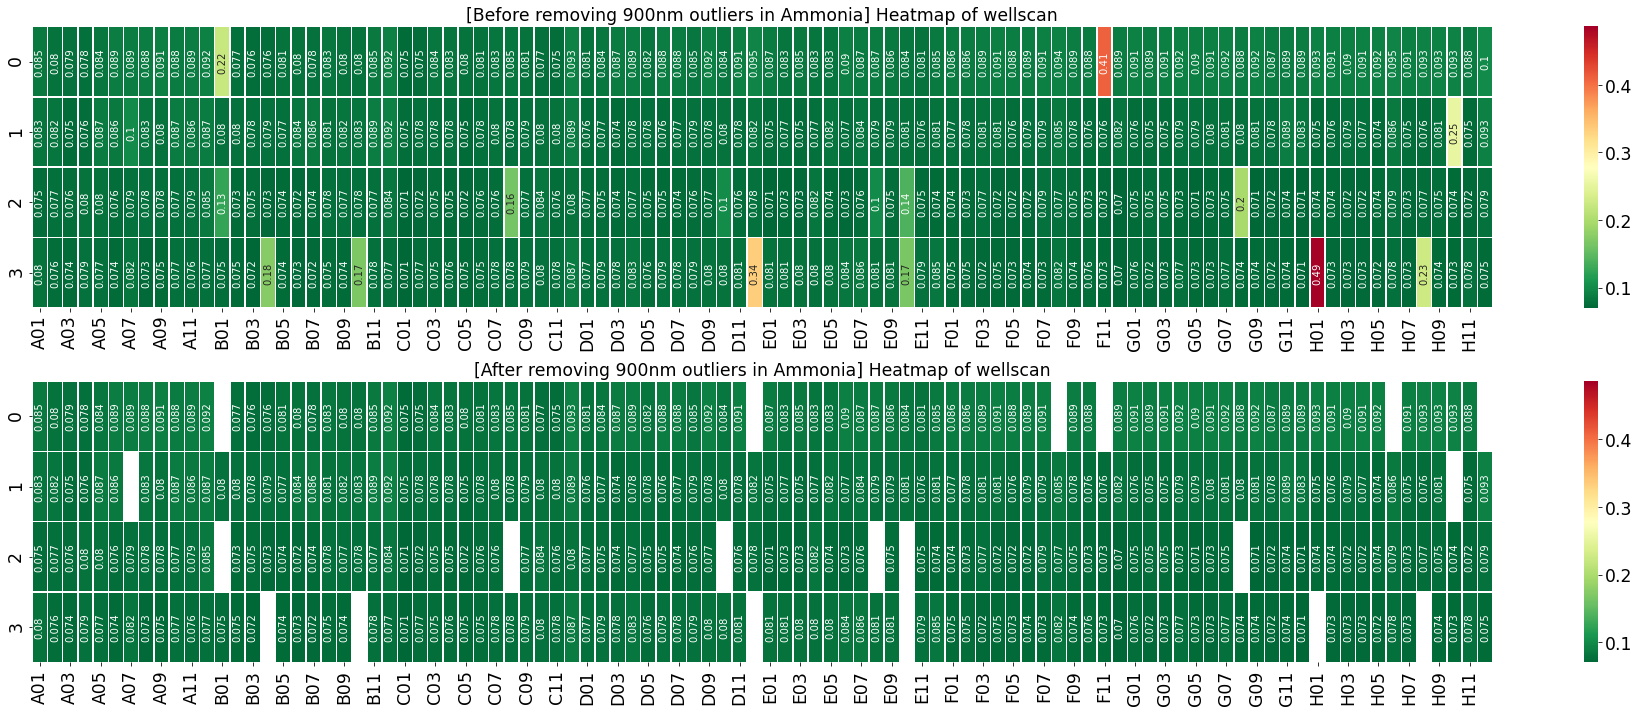

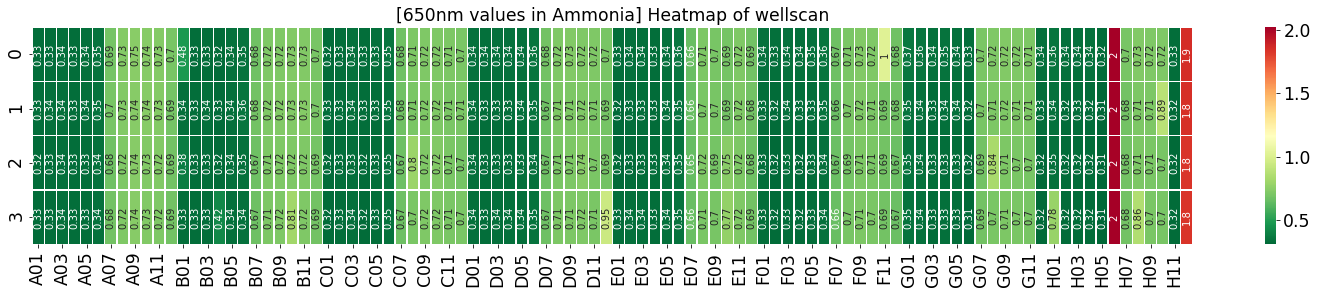

./240501_Ammonia/sample_metadata_Soil7_T0.csv
Currently using this fit:  [0.004487087370991127, 2.1418846361056683, -0.12848934521331828]
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.32660
A02    0.33115
A03    0.33765
A04    0.33285
A05    0.33590
        ...   
H08    0.71230
H09    0.70835
H10    0.70140
H11    0.31940
H12    1.83860
Name: Ammonia_OD650, Length: 96, dtype: float64
Subtracted blank value
A01    0.00020
A02    0.00475
A03    0.01125
A04    0.00645
A05    0.00950
        ...   
H08    0.38590
H09    0.38195
H10    0.37500
H11   -0.00700
H12    1.51220
Name: Ammonia_OD650, Length: 96, dtype: float64
Use the fit to infer Ammonia mM
A01    0.000000
A02    0.000123
A03    0.003158
A04    0.000916
A05    0.002341
         ...   
H08    0.180018
H09    0.178133
H10    0.174818
H11    0.000000
H12    0.736455
Name: Ammonia_mM, Length: 96, dtype: float64
      Nitrite_input  Nitrate_input  Ammonium_

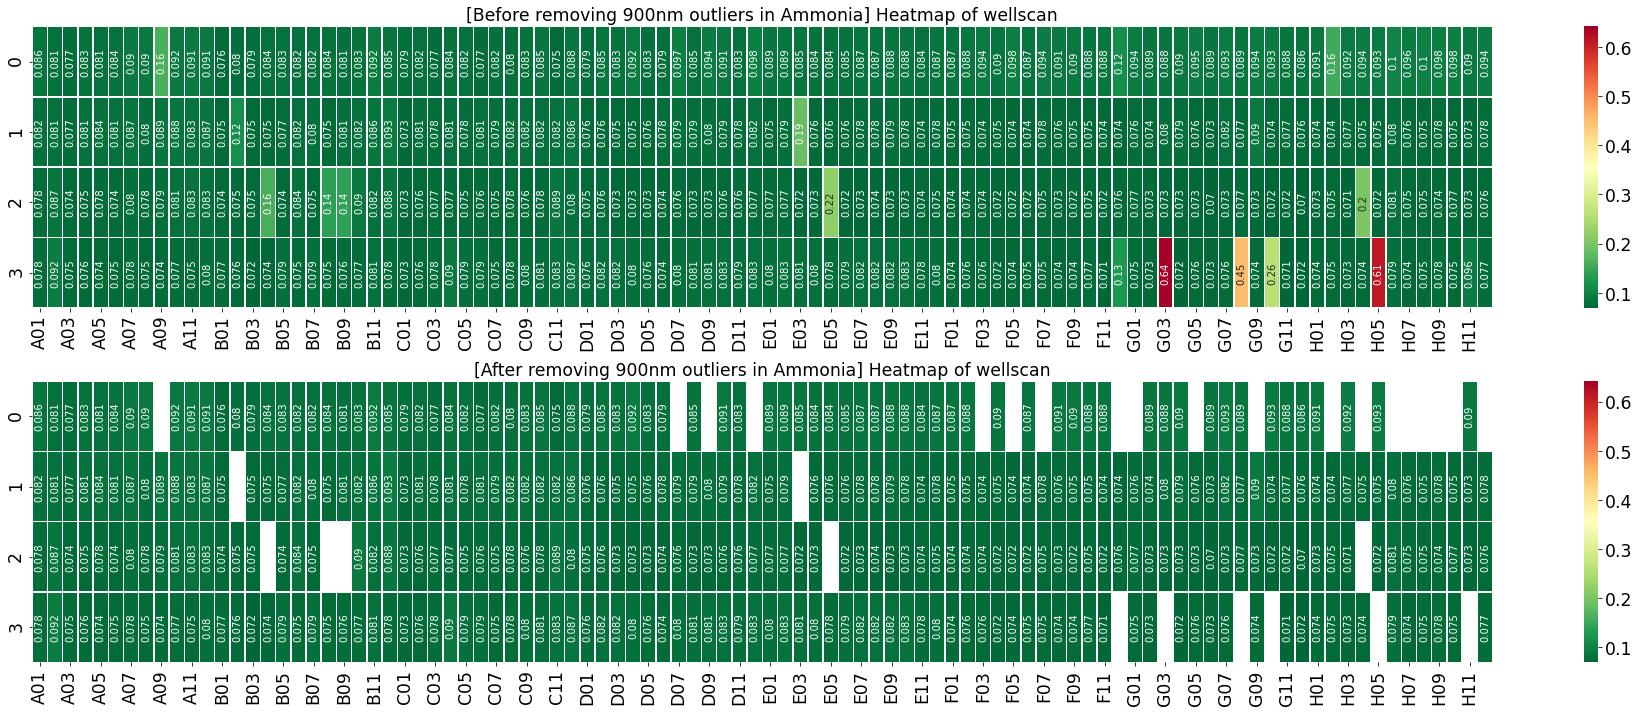

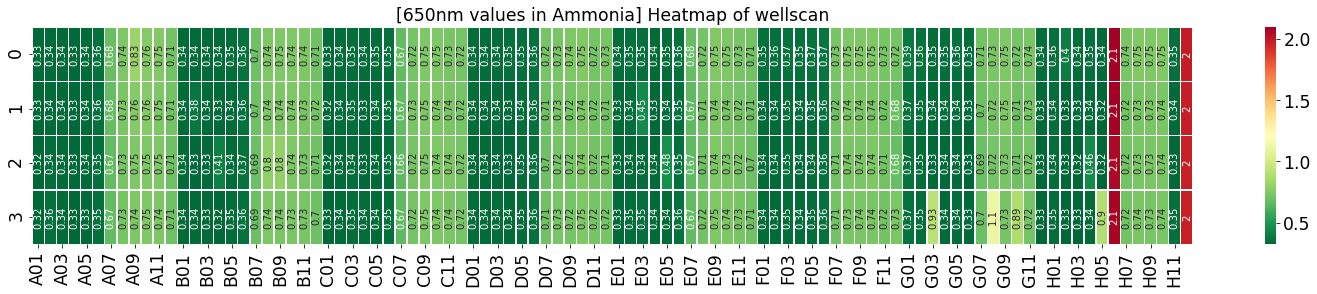

./240501_Ammonia/sample_metadata_Soil7_T1.csv
Currently using this fit:  [0.004487087370991127, 2.1418846361056683, -0.12848934521331828]
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.32605
A02    0.34165
A03    0.33760
A04    0.33030
A05    0.33670
        ...   
H08    0.73480
H09    0.73240
H10    0.73600
H11    0.33580
H12    1.98120
Name: Ammonia_OD650, Length: 96, dtype: float64
Subtracted blank value
A01   -0.00035
A02    0.01525
A03    0.01120
A04    0.00390
A05    0.01030
        ...   
H08    0.40840
H09    0.40600
H10    0.40960
H11    0.00940
H12    1.65480
Name: Ammonia_OD650, Length: 96, dtype: float64
Use the fit to infer Ammonia mM
A01    0.000000
A02    0.005026
A03    0.003135
A04    0.000000
A05    0.002714
         ...   
H08    0.190761
H09    0.189615
H10    0.191335
H11    0.002294
H12    0.809839
Name: Ammonia_mM, Length: 96, dtype: float64
      Nitrite_input  Nitrate_input  Ammonium_

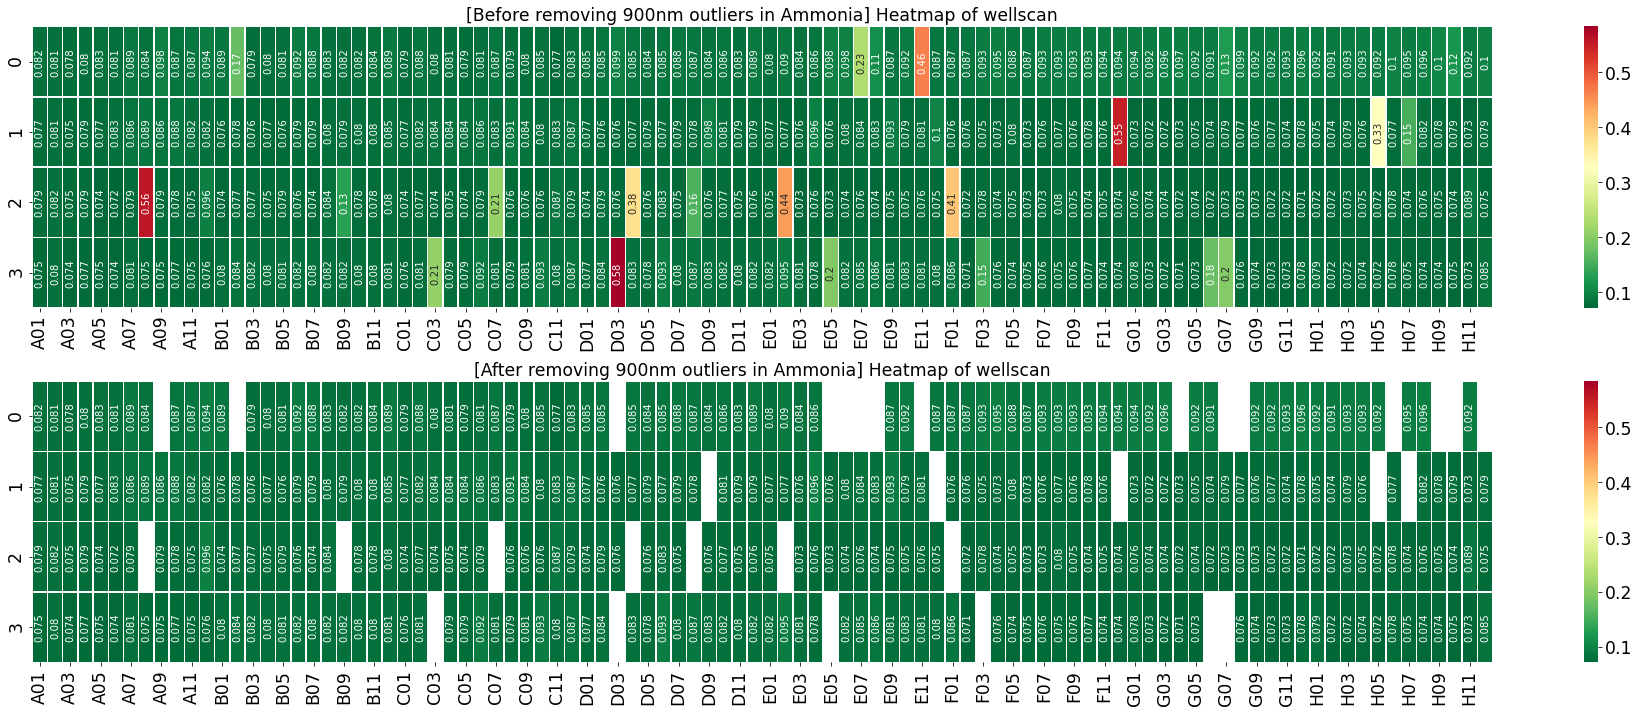

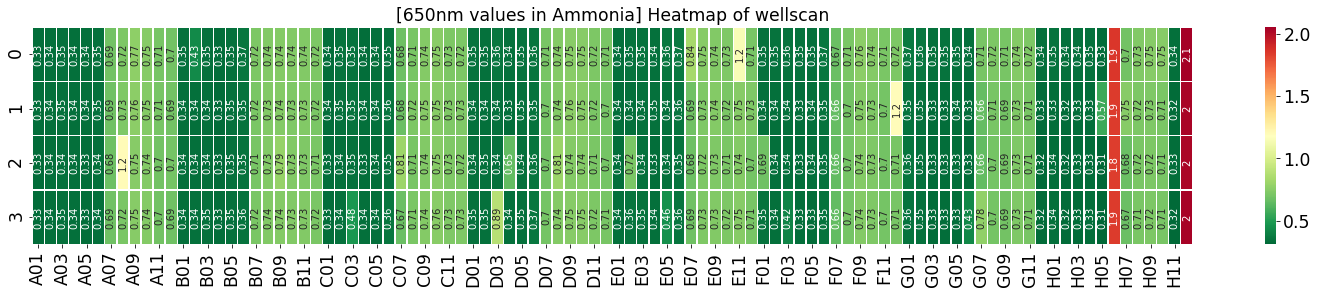

./240501_Ammonia/sample_metadata_Soil7_T2.csv
Currently using this fit:  [0.004487087370991127, 2.1418846361056683, -0.12848934521331828]
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.32805
A02    0.33885
A03    0.34620
A04    0.33905
A05    0.33510
        ...   
H08    0.71955
H09    0.72400
H10    0.70680
H11    0.32810
H12    2.03700
Name: Ammonia_OD650, Length: 96, dtype: float64
Subtracted blank value
A01    0.00165
A02    0.01245
A03    0.01980
A04    0.01265
A05    0.00870
        ...   
H08    0.39315
H09    0.39760
H10    0.38040
H11    0.00170
H12    1.71060
Name: Ammonia_OD650, Length: 96, dtype: float64
Use the fit to infer Ammonia mM
A01    0.000000
A02    0.003719
A03    0.007152
A04    0.003812
A05    0.001967
         ...   
H08    0.183478
H09    0.185603
H10    0.177393
H11    0.000000
H12    0.838750
Name: Ammonia_mM, Length: 96, dtype: float64
      Nitrite_input  Nitrate_input  Ammonium_

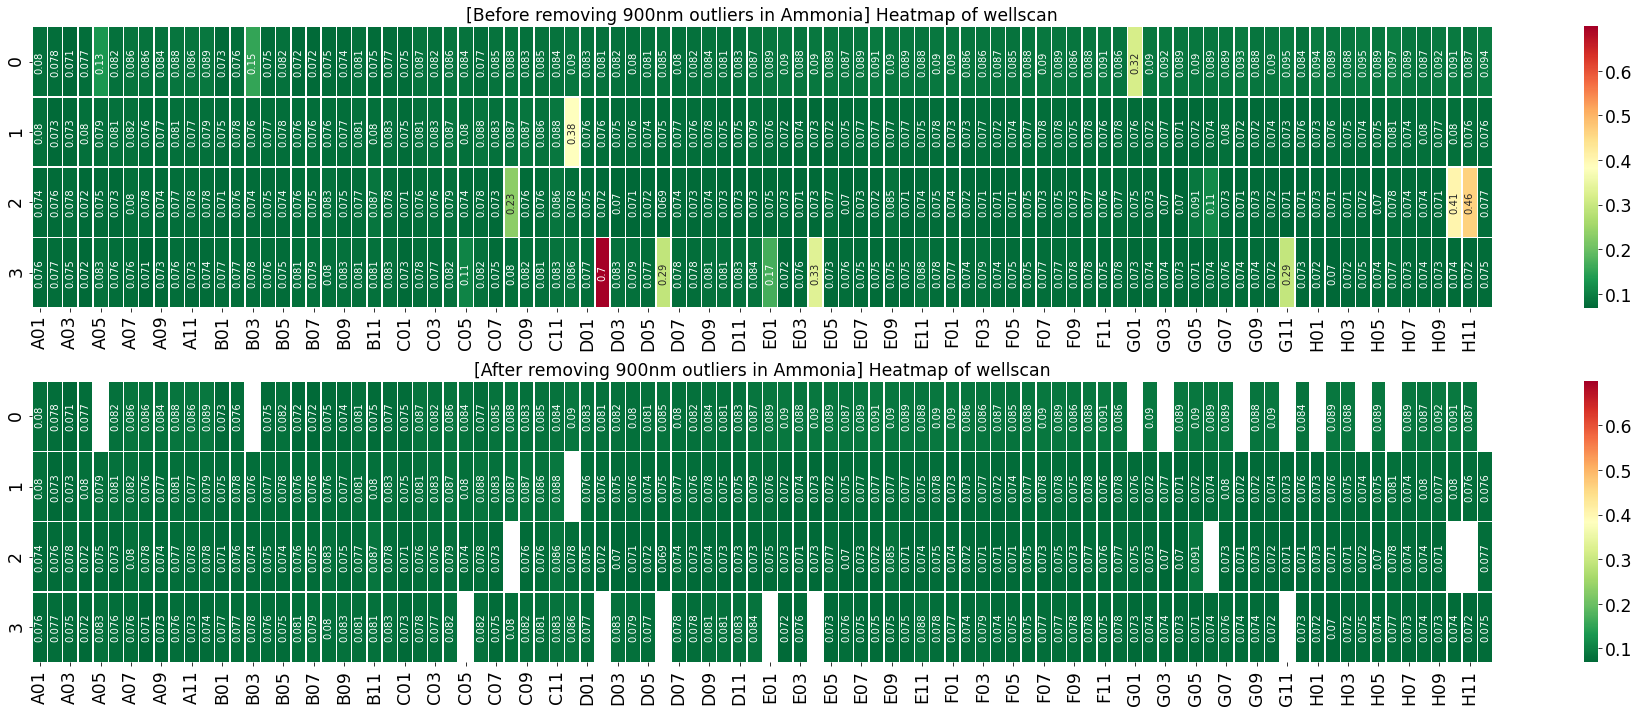

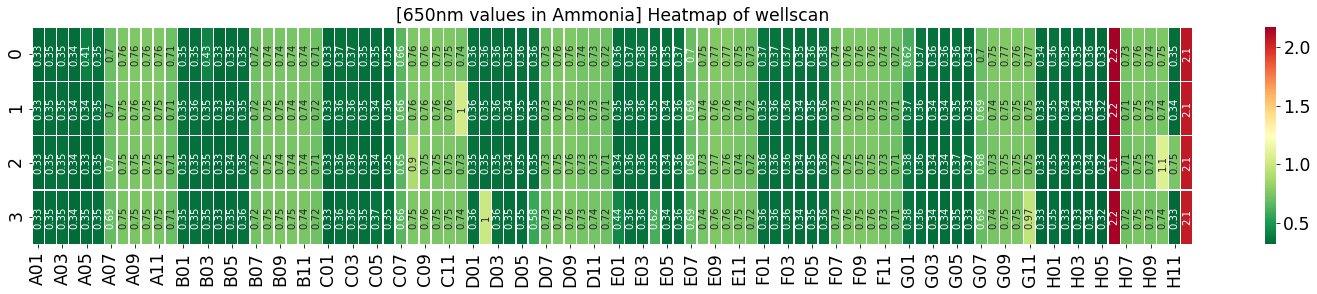

./240501_Ammonia/sample_metadata_Soil7_T3.csv
Currently using this fit:  [0.004487087370991127, 2.1418846361056683, -0.12848934521331828]
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.32845
A02    0.35110
A03    0.34985
A04    0.33955
A05    0.33900
        ...   
H08    0.75140
H09    0.72775
H10    0.74280
H11    0.33700
H12    2.06360
Name: Ammonia_OD650, Length: 96, dtype: float64
Subtracted blank value
A01    0.00205
A02    0.02470
A03    0.02345
A04    0.01315
A05    0.01260
        ...   
H08    0.42500
H09    0.40135
H10    0.41640
H11    0.01060
H12    1.73720
Name: Ammonia_OD650, Length: 96, dtype: float64
Use the fit to infer Ammonia mM
A01    0.000000
A02    0.009442
A03    0.008858
A04    0.004046
A05    0.003789
         ...   
H08    0.198697
H09    0.187393
H10    0.194585
H11    0.002854
H12    0.852571
Name: Ammonia_mM, Length: 96, dtype: float64
      Nitrite_input  Nitrate_input  Ammonium_

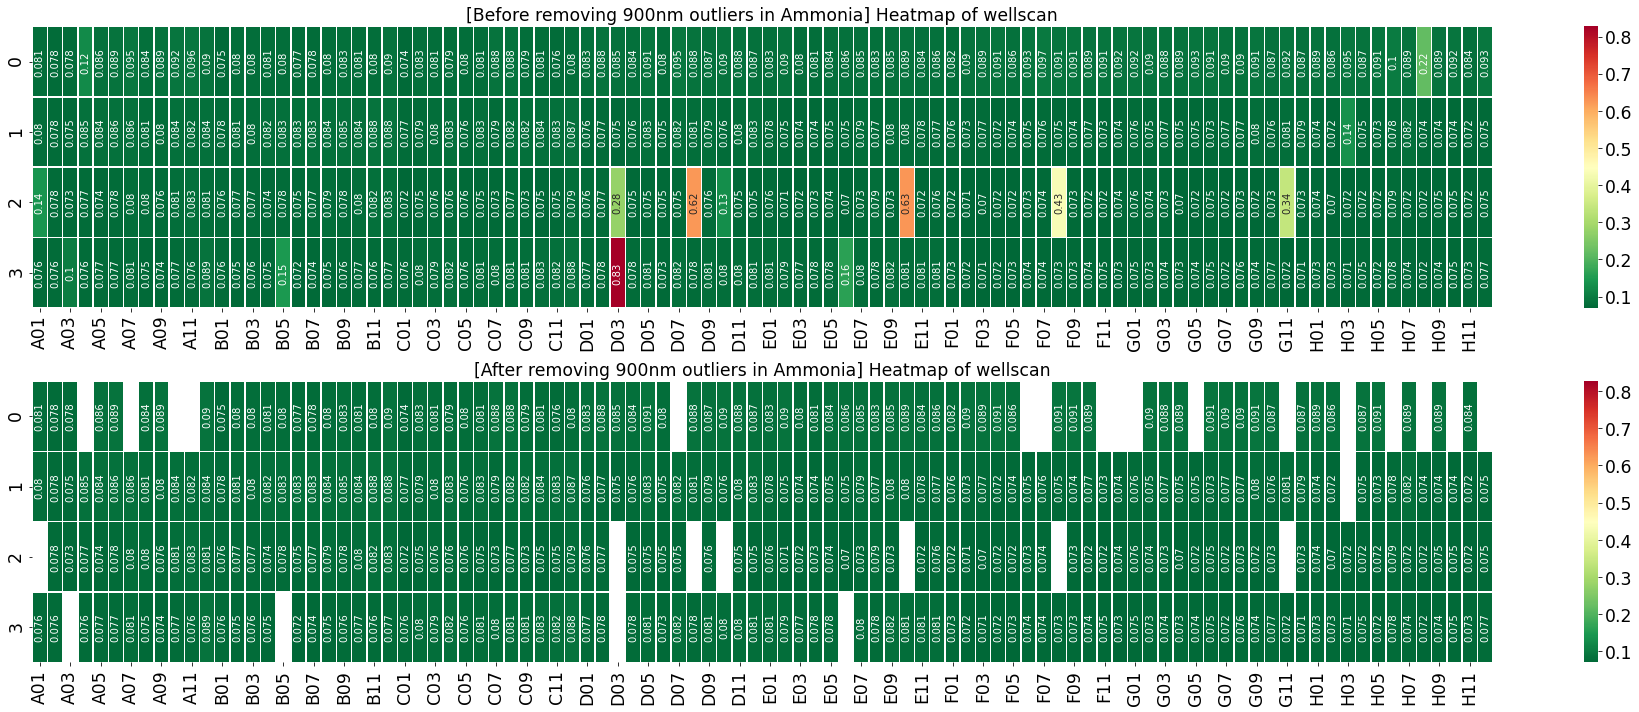

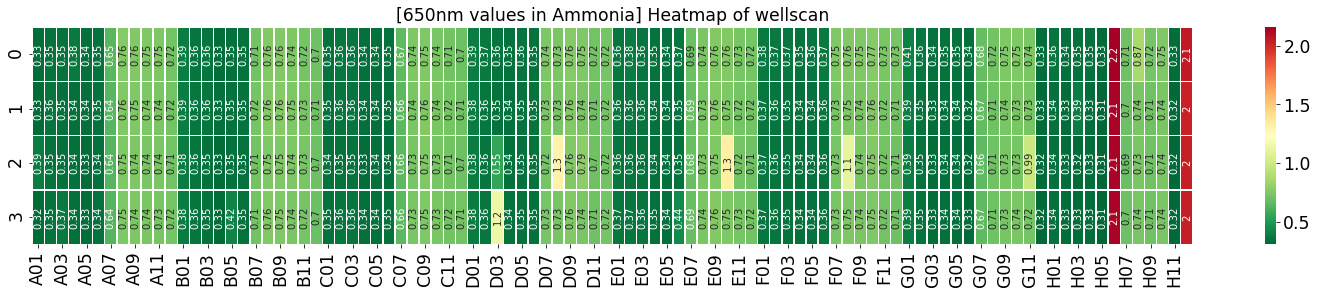

./240501_Ammonia/sample_metadata_Soil7_T4.csv
Currently using this fit:  [0.004487087370991127, 2.1418846361056683, -0.12848934521331828]
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.32690
A02    0.35310
A03    0.34600
A04    0.33720
A05    0.33625
        ...   
H08    0.73530
H09    0.70855
H10    0.73750
H11    0.31820
H12    2.03110
Name: Ammonia_OD650, Length: 96, dtype: float64
Subtracted blank value
A01    0.00050
A02    0.02670
A03    0.01960
A04    0.01080
A05    0.00985
        ...   
H08    0.40890
H09    0.38215
H10    0.41110
H11   -0.00820
H12    1.70470
Name: Ammonia_OD650, Length: 96, dtype: float64
Use the fit to infer Ammonia mM
A01    0.000000
A02    0.010377
A03    0.007059
A04    0.002948
A05    0.002504
         ...   
H08    0.191000
H09    0.178228
H10    0.192051
H11    0.000000
H12    0.835688
Name: Ammonia_mM, Length: 96, dtype: float64
      Nitrite_input  Nitrate_input  Ammonium_

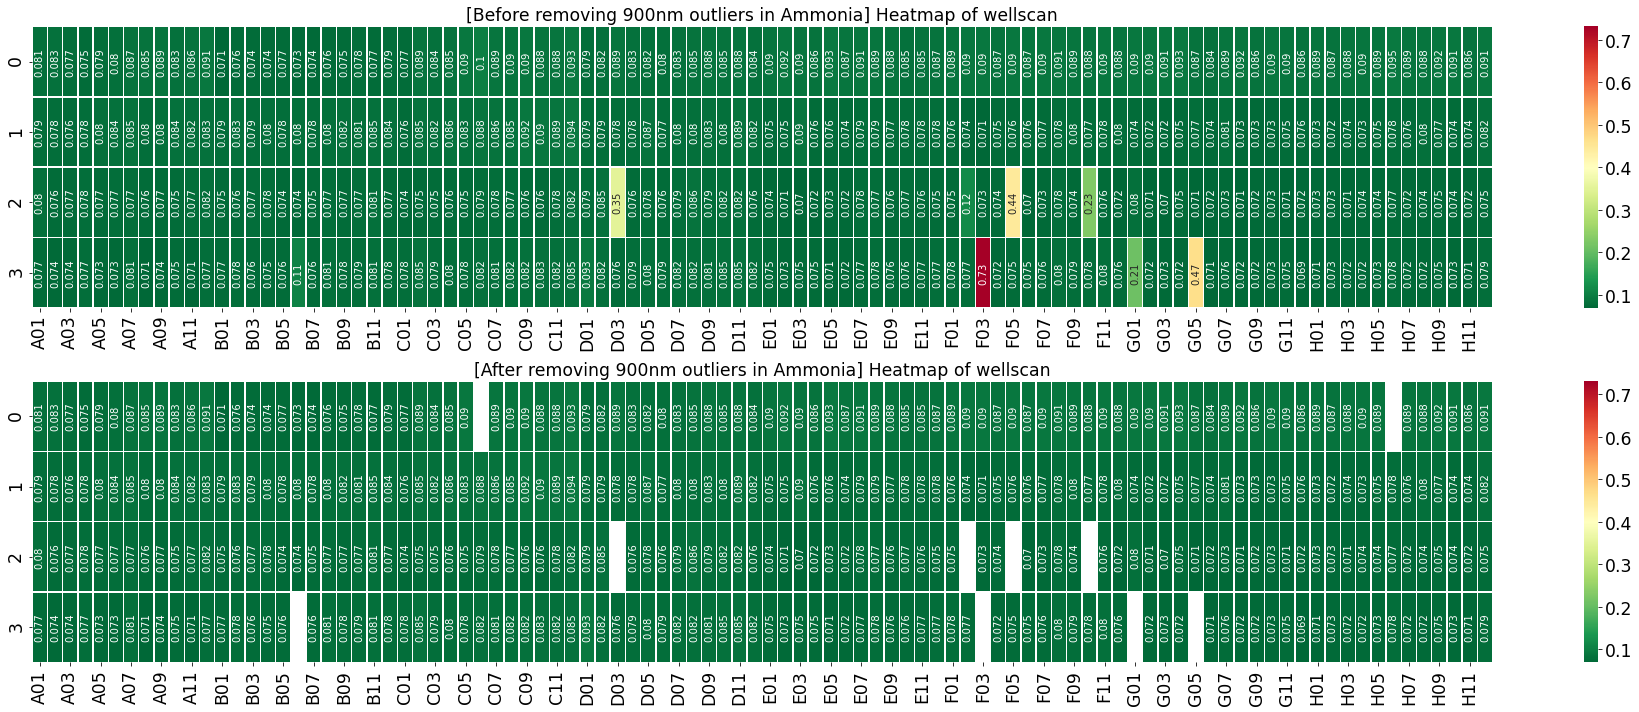

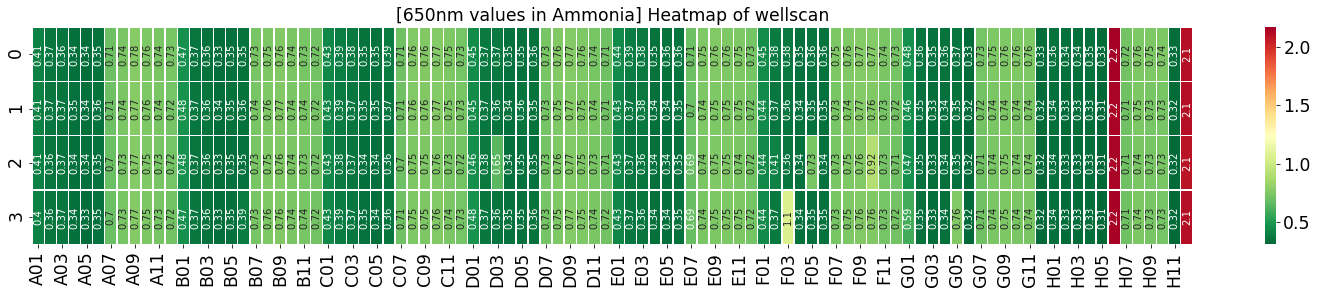

./240501_Ammonia/sample_metadata_Soil7_T5.csv
Currently using this fit:  [0.004487087370991127, 2.1418846361056683, -0.12848934521331828]
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.40645
A02    0.36645
A03    0.36610
A04    0.34390
A05    0.33765
        ...   
H08    0.74525
H09    0.73480
H10    0.72980
H11    0.32115
H12    2.10525
Name: Ammonia_OD650, Length: 96, dtype: float64
Subtracted blank value
A01    0.08005
A02    0.04005
A03    0.03970
A04    0.01750
A05    0.01125
        ...   
H08    0.41885
H09    0.40840
H10    0.40340
H11   -0.00525
H12    1.77885
Name: Ammonia_OD650, Length: 96, dtype: float64
Use the fit to infer Ammonia mM
A01    0.035354
A02    0.016620
A03    0.016456
A04    0.006078
A05    0.003158
         ...   
H08    0.195756
H09    0.190761
H10    0.188373
H11    0.000000
H12    0.874264
Name: Ammonia_mM, Length: 96, dtype: float64
      Nitrite_input  Nitrate_input  Ammonium_

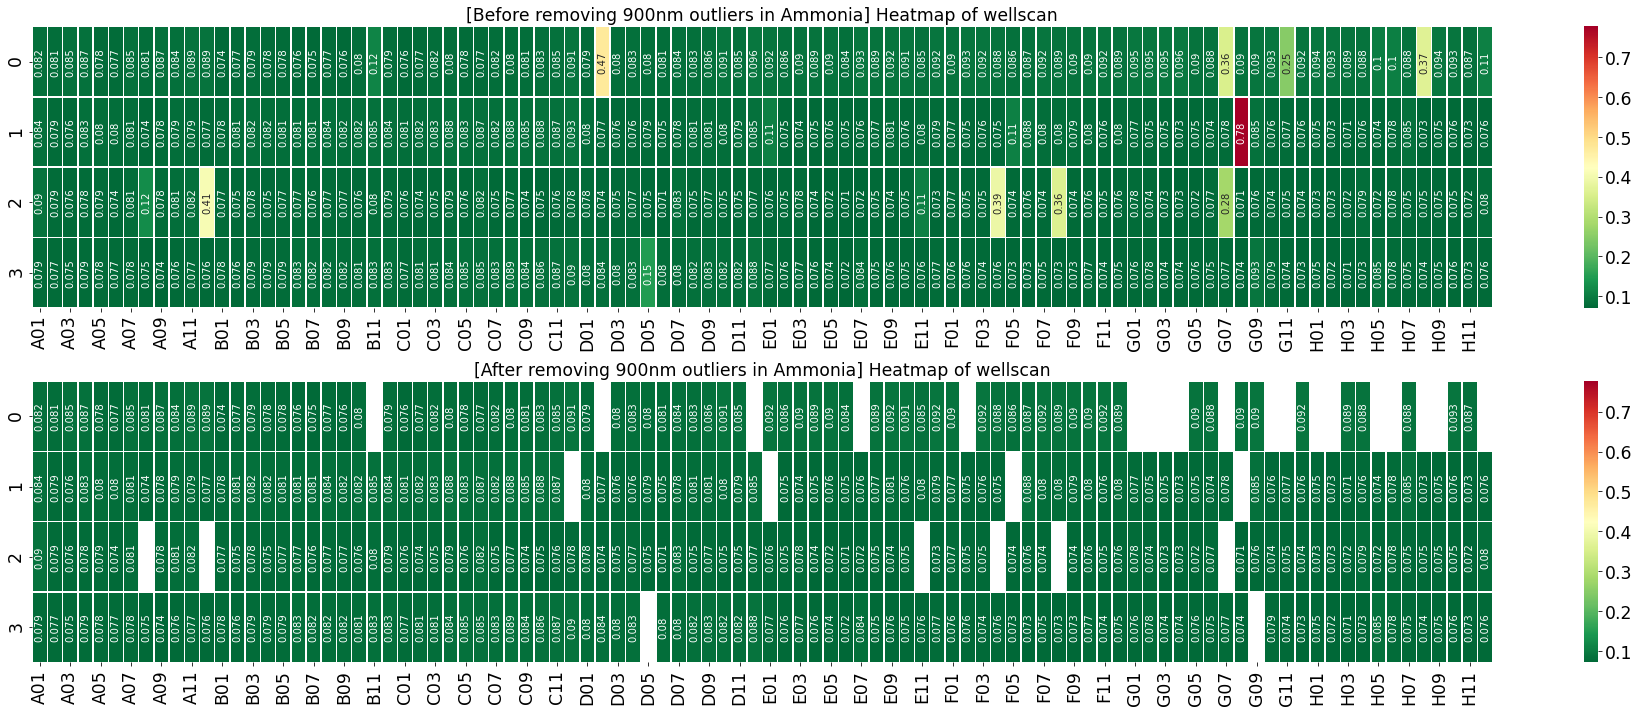

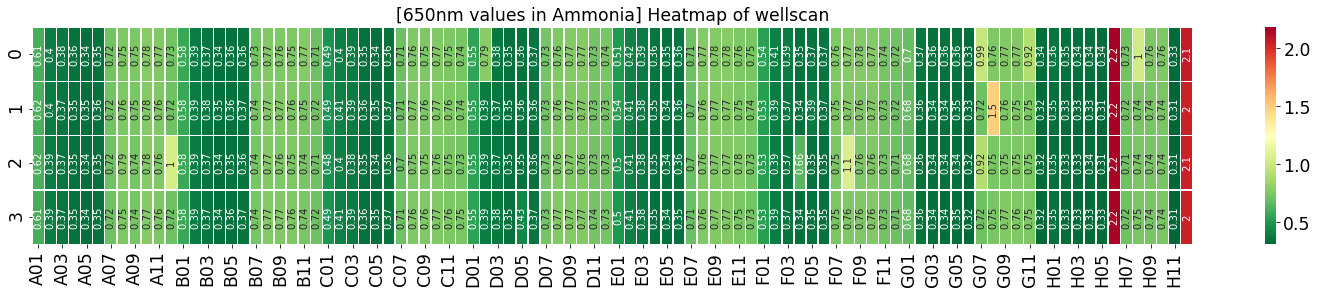

./240501_Ammonia/sample_metadata_Soil7_T6.csv
Currently using this fit:  [0.004487087370991127, 2.1418846361056683, -0.12848934521331828]
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.61715
A02    0.39555
A03    0.37280
A04    0.35075
A05    0.34365
        ...   
H08    0.74450
H09    0.73960
H10    0.74295
H11    0.31430
H12    2.04740
Name: Ammonia_OD650, Length: 96, dtype: float64
Subtracted blank value
A01    0.29075
A02    0.06915
A03    0.04640
A04    0.02435
A05    0.01725
        ...   
H08    0.41810
H09    0.41320
H10    0.41655
H11   -0.01210
H12    1.72100
Name: Ammonia_OD650, Length: 96, dtype: float64
Use the fit to infer Ammonia mM
A01    0.134739
A02    0.030245
A03    0.019591
A04    0.009279
A05    0.005961
         ...   
H08    0.195397
H09    0.193055
H10    0.194656
H11    0.000000
H12    0.844151
Name: Ammonia_mM, Length: 96, dtype: float64
      Nitrite_input  Nitrate_input  Ammonium_

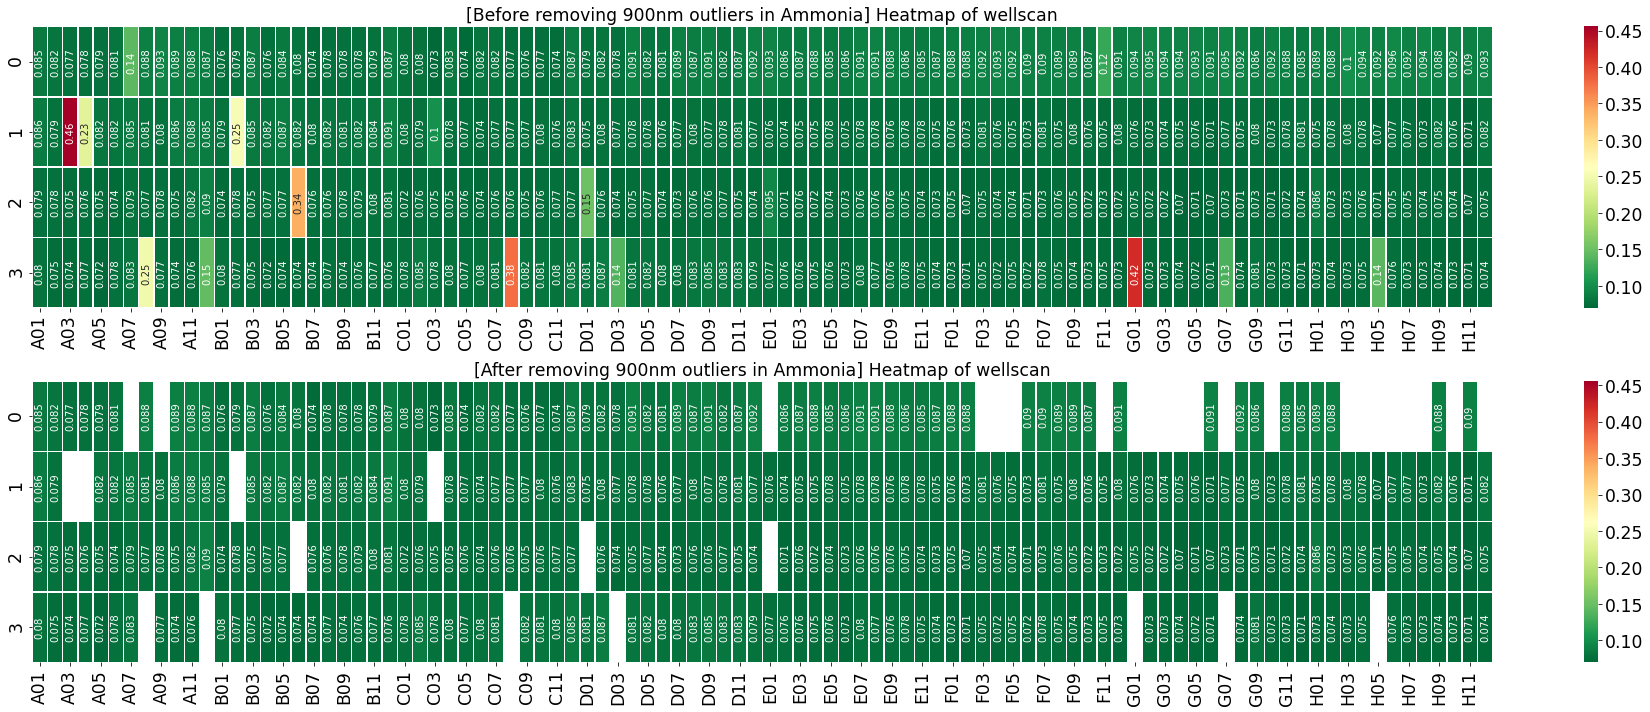

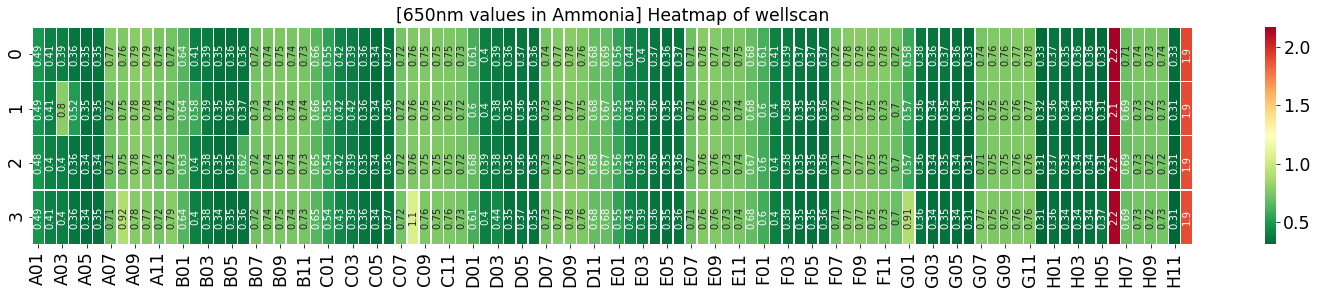

./240501_Ammonia/sample_metadata_Soil7_T7.csv
Currently using this fit:  [0.004487087370991127, 2.1418846361056683, -0.12848934521331828]
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.49000
A02    0.40625
A03    0.39560
A04    0.36070
A05    0.34455
        ...   
H08    0.72720
H09    0.72185
H10    0.72660
H11    0.31380
H12    1.89250
Name: Ammonia_OD650, Length: 96, dtype: float64
Subtracted blank value
A01    0.16360
A02    0.07985
A03    0.06920
A04    0.03430
A05    0.01815
        ...   
H08    0.40080
H09    0.39545
H10    0.40020
H11   -0.01260
H12    1.56610
Name: Ammonia_OD650, Length: 96, dtype: float64
Use the fit to infer Ammonia mM
A01    0.074620
A02    0.035260
A03    0.030268
A04    0.013931
A05    0.006381
         ...   
H08    0.187131
H09    0.184576
H10    0.186844
H11    0.000000
H12    0.764109
Name: Ammonia_mM, Length: 96, dtype: float64
      Nitrite_input  Nitrate_input  Ammonium_

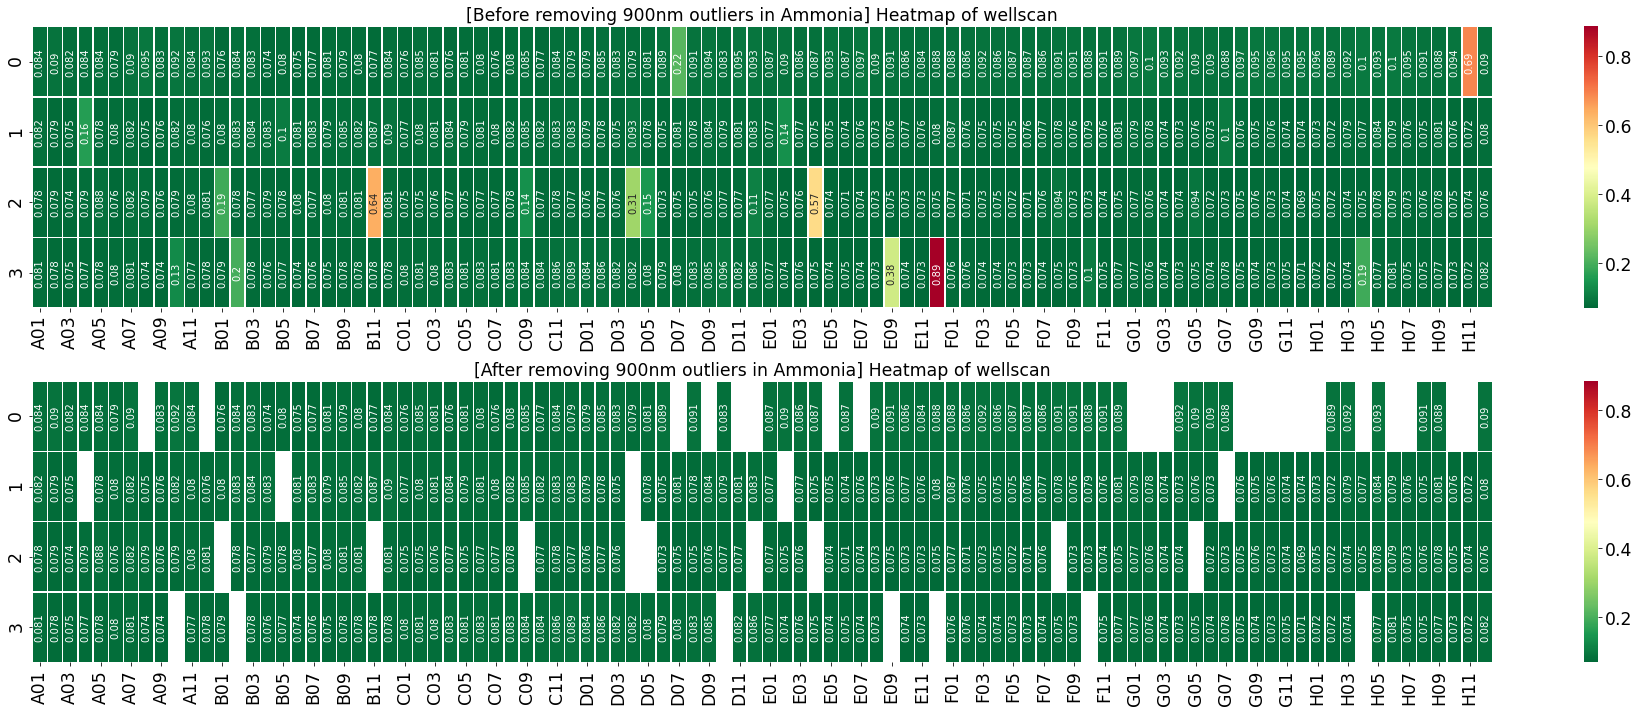

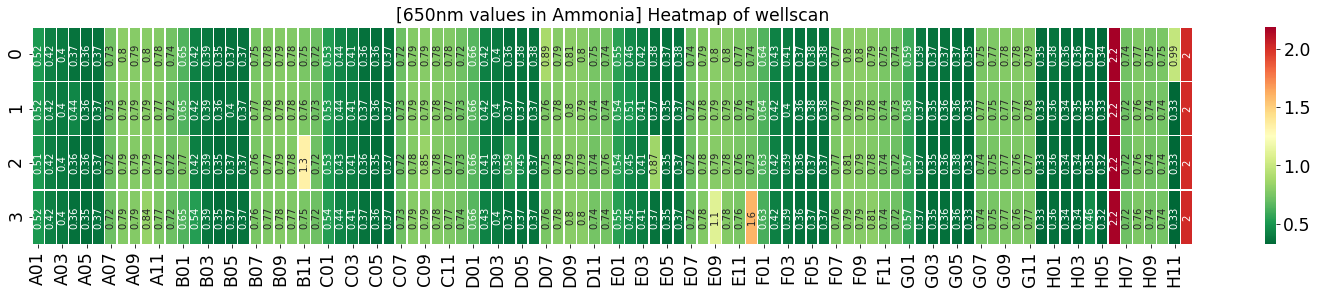

./240501_Ammonia/sample_metadata_Soil7_T8.csv
Currently using this fit:  [0.004487087370991127, 2.1418846361056683, -0.12848934521331828]
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.51620
A02    0.41840
A03    0.39670
A04    0.36410
A05    0.35690
        ...   
H08    0.76195
H09    0.74045
H10    0.73900
H11    0.32580
H12    2.01990
Name: Ammonia_OD650, Length: 96, dtype: float64
Subtracted blank value
A01    0.18980
A02    0.09200
A03    0.07030
A04    0.03770
A05    0.03050
        ...   
H08    0.43555
H09    0.41405
H10    0.41260
H11   -0.00060
H12    1.69350
Name: Ammonia_OD650, Length: 96, dtype: float64
Use the fit to infer Ammonia mM
A01    0.086972
A02    0.040959
A03    0.030783
A04    0.015521
A05    0.012154
         ...   
H08    0.203744
H09    0.193461
H10    0.192768
H11    0.000000
H12    0.829878
Name: Ammonia_mM, Length: 96, dtype: float64
      Nitrite_input  Nitrate_input  Ammonium_

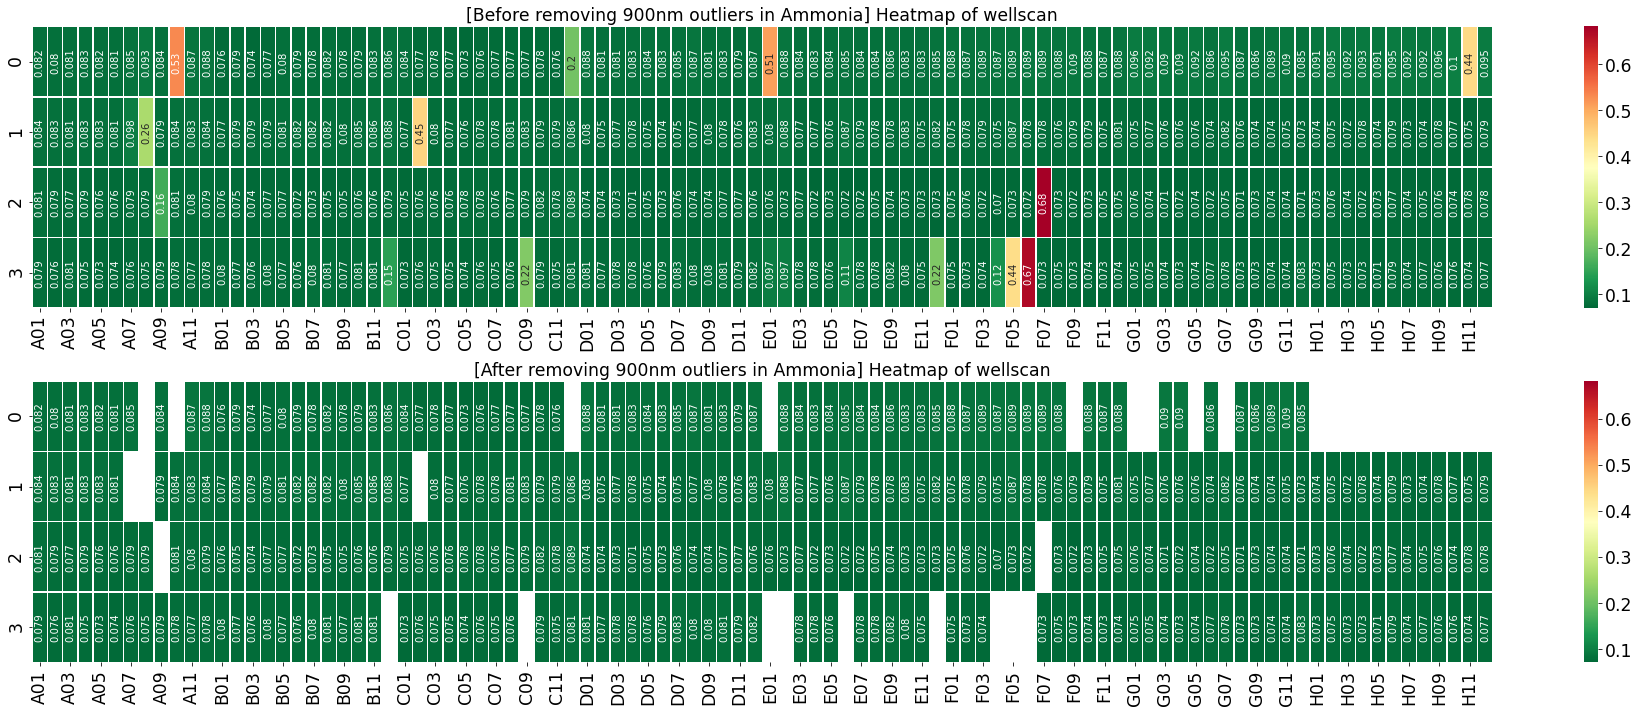

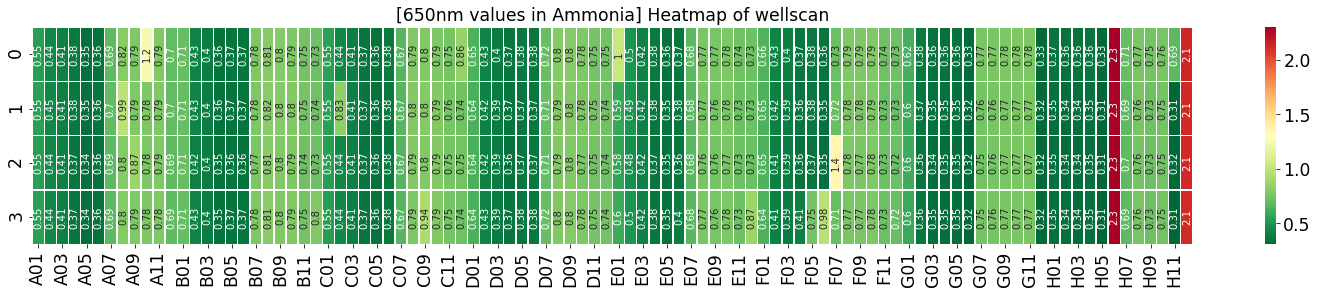

./240501_Ammonia/sample_metadata_Soil7_T9.csv
Currently using this fit:  [0.004487087370991127, 2.1418846361056683, -0.12848934521331828]
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.54905
A02    0.44320
A03    0.41330
A04    0.37545
A05    0.34630
        ...   
H08    0.75950
H09    0.73110
H10    0.74540
H11    0.31400
H12    2.12490
Name: Ammonia_OD650, Length: 96, dtype: float64
Subtracted blank value
A01    0.22265
A02    0.11680
A03    0.08690
A04    0.04905
A05    0.01990
        ...   
H08    0.43310
H09    0.40470
H10    0.41900
H11   -0.01240
H12    1.79850
Name: Ammonia_OD650, Length: 96, dtype: float64
Use the fit to infer Ammonia mM
A01    0.102486
A02    0.052602
A03    0.038566
A04    0.020832
A05    0.007199
         ...   
H08    0.202572
H09    0.188994
H10    0.195828
H11    0.000000
H12    0.884520
Name: Ammonia_mM, Length: 96, dtype: float64
      Nitrite_input  Nitrate_input  Ammonium_

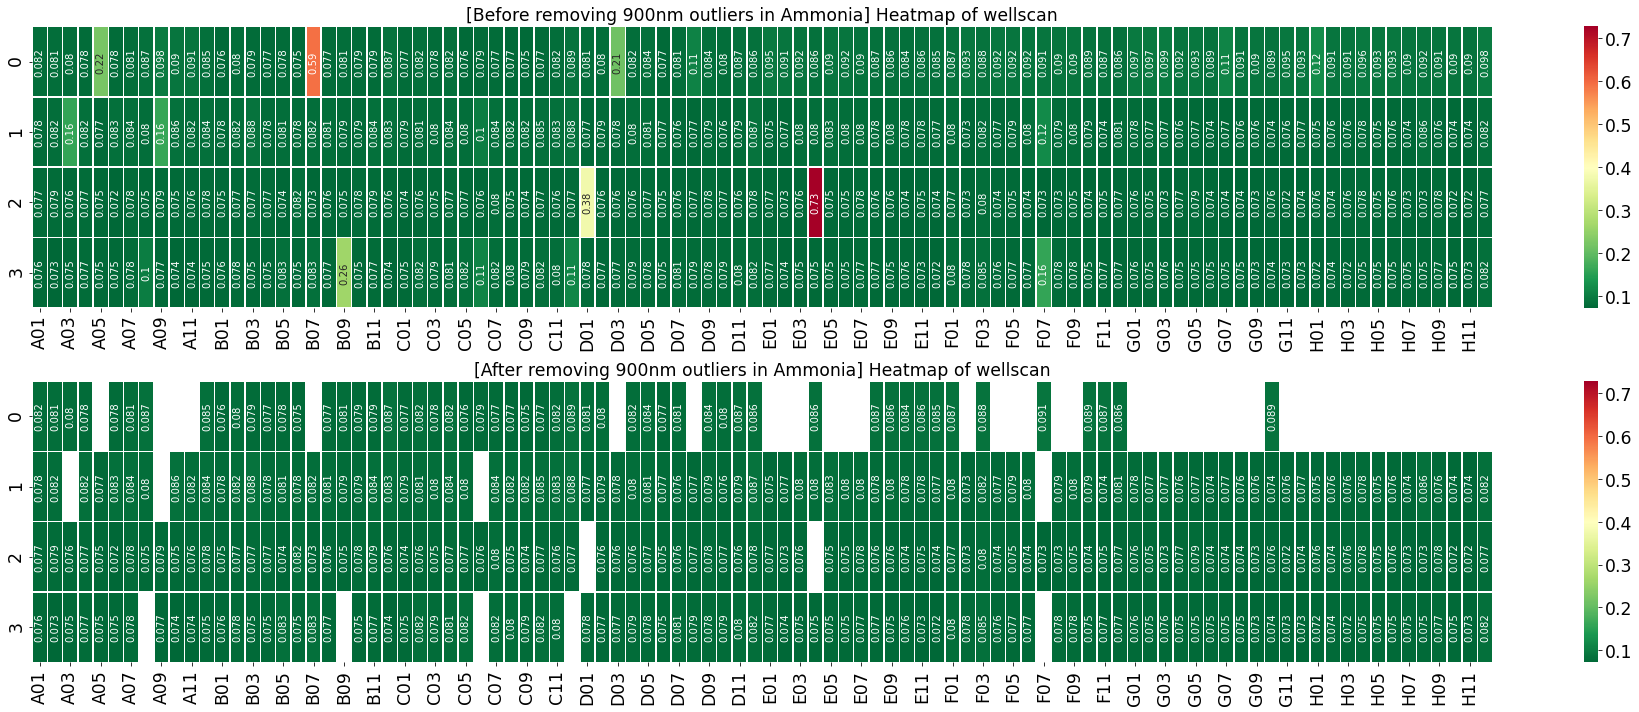

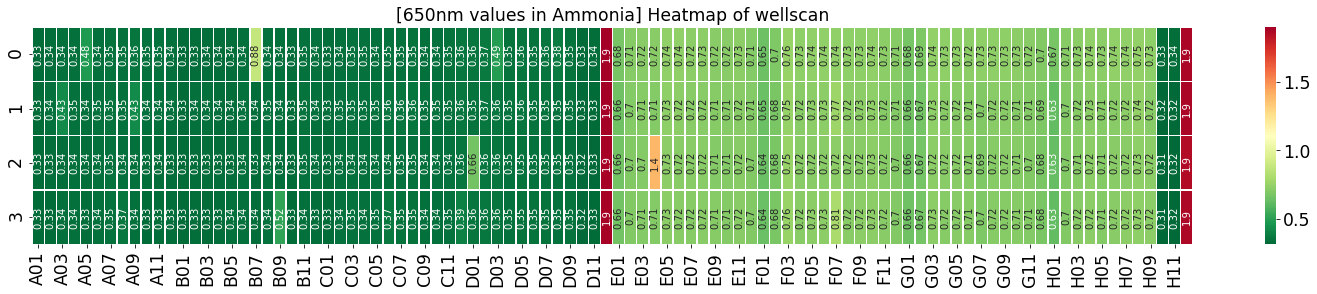

./240501_Ammonia/sample_metadata_Soil10_T0.csv
Currently using this fit:  [0.004487087370991127, 2.1418846361056683, -0.12848934521331828]
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.32895
A02    0.33525
A03    0.33770
A04    0.34125
A05    0.33520
        ...   
H08    0.73420
H09    0.72280
H10    0.31300
H11    0.31940
H12    1.87750
Name: Ammonia_OD650, Length: 96, dtype: float64
Subtracted blank value
A01    0.00255
A02    0.00885
A03    0.01130
A04    0.01485
A05    0.00880
        ...   
H08    0.40780
H09    0.39640
H10   -0.01340
H11   -0.00700
H12    1.55110
Name: Ammonia_OD650, Length: 96, dtype: float64
Use the fit to infer Ammonia mM
A01    0.000000
A02    0.002037
A03    0.003181
A04    0.004840
A05    0.002014
         ...   
H08    0.190475
H09    0.185030
H10    0.000000
H11    0.000000
H12    0.756403
Name: Ammonia_mM, Length: 96, dtype: float64
      Nitrite_input  Nitrate_input  Ammonium

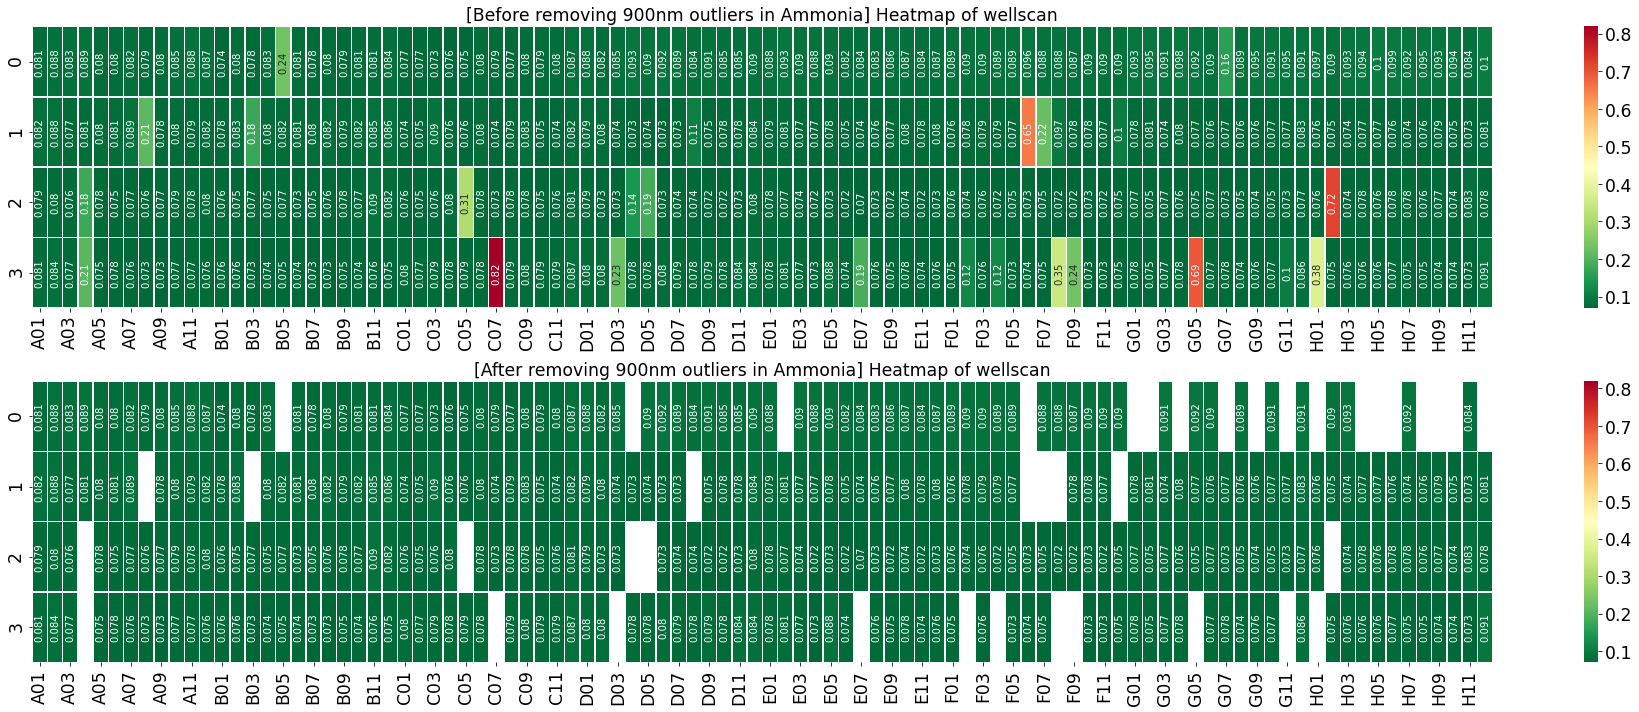

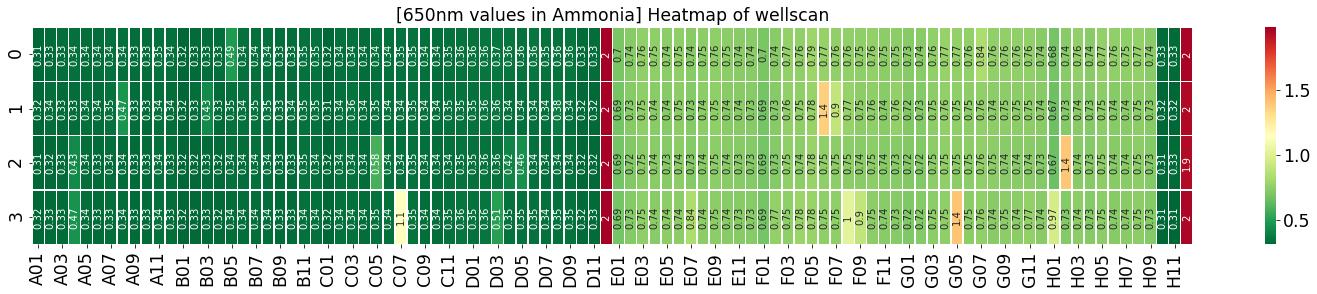

./240501_Ammonia/sample_metadata_Soil10_T1.csv
Currently using this fit:  [0.004487087370991127, 2.1418846361056683, -0.12848934521331828]
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.31450
A02    0.32950
A03    0.33025
A04    0.33815
A05    0.33705
        ...   
H08    0.74820
H09    0.72930
H10    0.31290
H11    0.32150
H12    1.95010
Name: Ammonia_OD650, Length: 96, dtype: float64
Subtracted blank value
A01   -0.01190
A02    0.00310
A03    0.00385
A04    0.01175
A05    0.01065
        ...   
H08    0.42180
H09    0.40290
H10   -0.01350
H11   -0.00490
H12    1.62370
Name: Ammonia_OD650, Length: 96, dtype: float64
Use the fit to infer Ammonia mM
A01    0.000000
A02    0.000000
A03    0.000000
A04    0.003392
A05    0.002878
         ...   
H08    0.197166
H09    0.188134
H10    0.000000
H11    0.000000
H12    0.793773
Name: Ammonia_mM, Length: 96, dtype: float64
      Nitrite_input  Nitrate_input  Ammonium

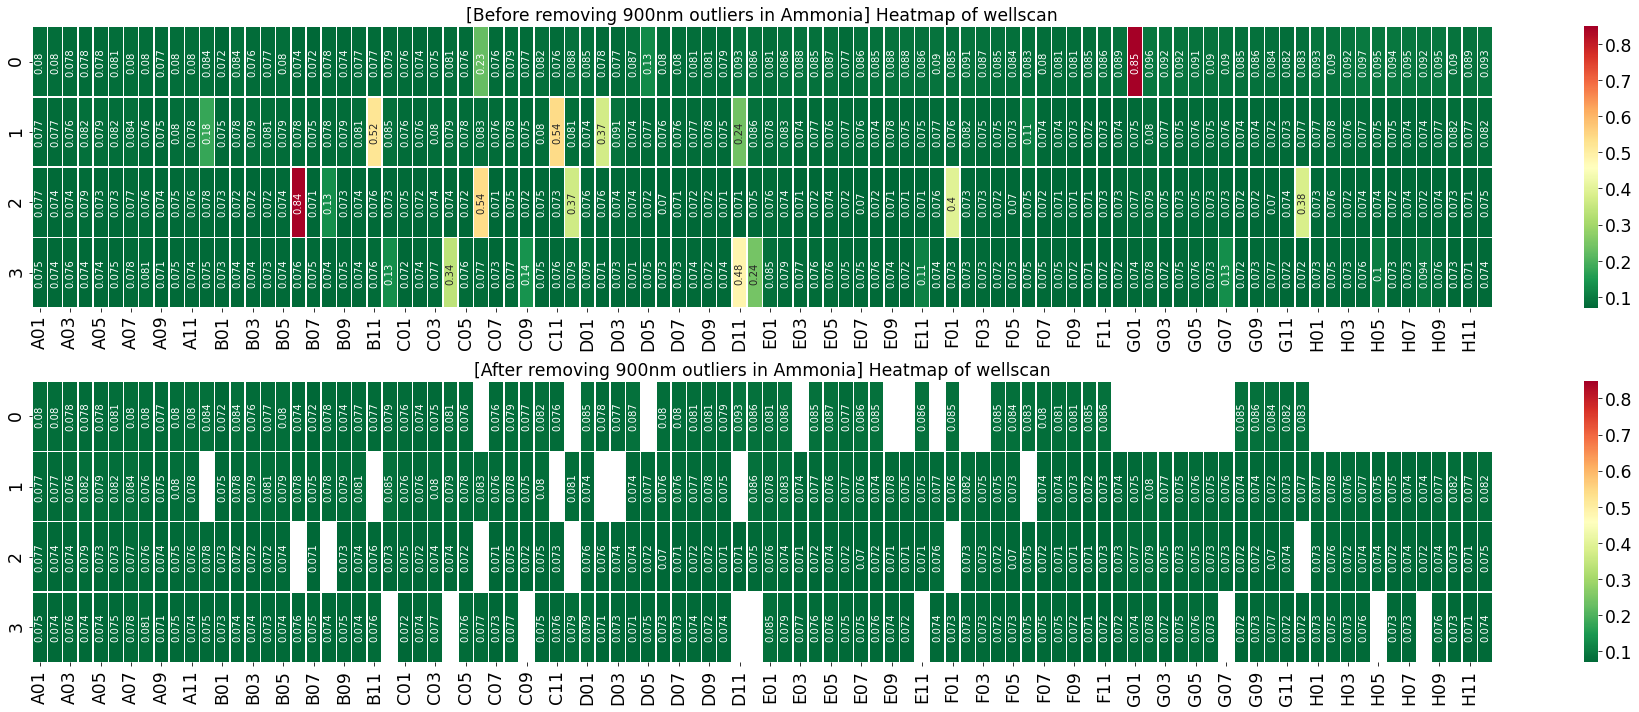

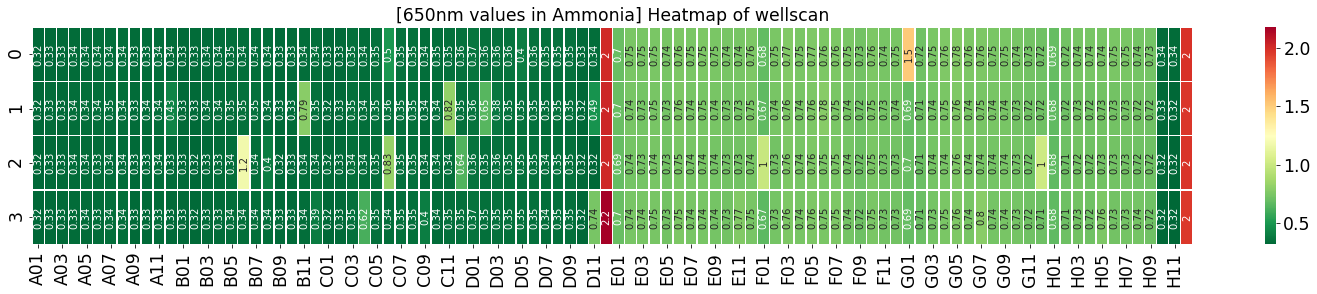

./240501_Ammonia/sample_metadata_Soil10_T2.csv
Currently using this fit:  [0.004487087370991127, 2.1418846361056683, -0.12848934521331828]
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.32035
A02    0.32860
A03    0.32890
A04    0.33685
A05    0.33760
        ...   
H08    0.72315
H09    0.71940
H10    0.31970
H11    0.31800
H12    1.97470
Name: Ammonia_OD650, Length: 96, dtype: float64
Subtracted blank value
A01   -0.00605
A02    0.00220
A03    0.00250
A04    0.01045
A05    0.01120
        ...   
H08    0.39675
H09    0.39300
H10   -0.00670
H11   -0.00840
H12    1.64830
Name: Ammonia_OD650, Length: 96, dtype: float64
Use the fit to infer Ammonia mM
A01    0.000000
A02    0.000000
A03    0.000000
A04    0.002784
A05    0.003135
         ...   
H08    0.185197
H09    0.183406
H10    0.000000
H11    0.000000
H12    0.806478
Name: Ammonia_mM, Length: 96, dtype: float64
      Nitrite_input  Nitrate_input  Ammonium

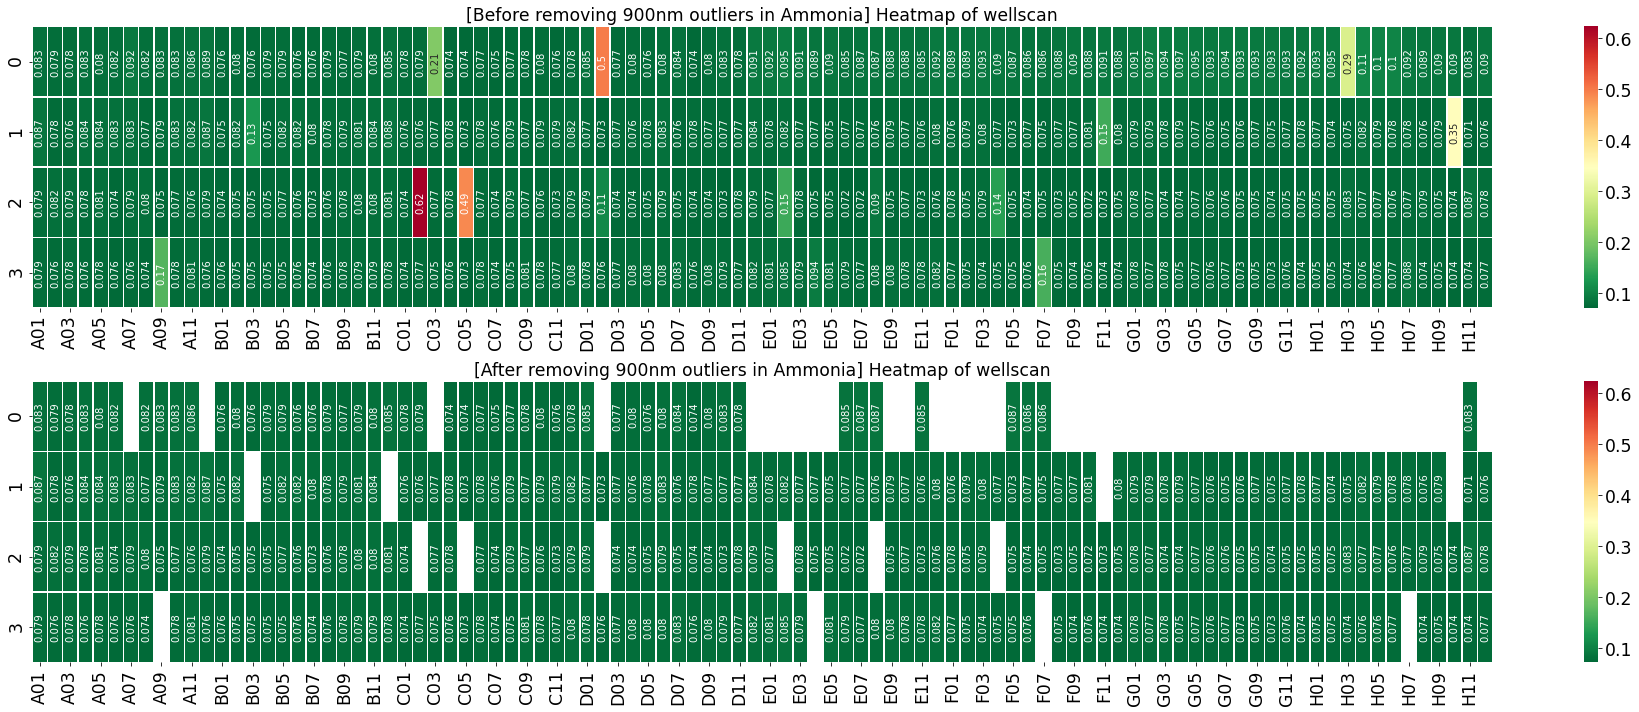

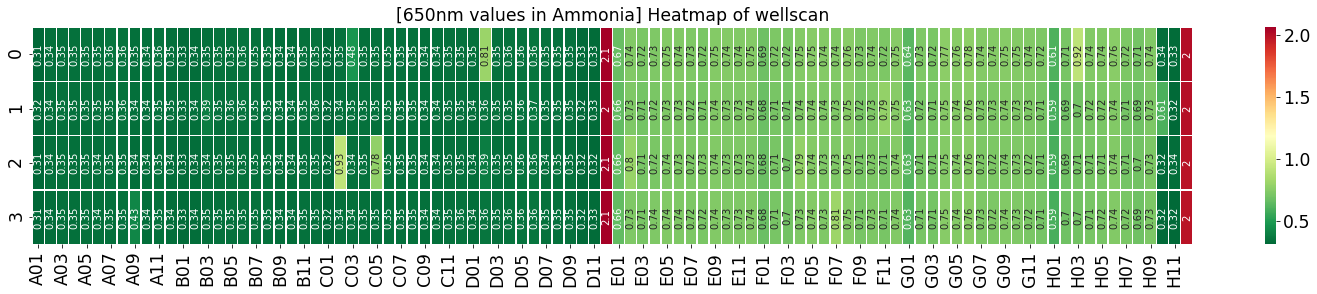

./240501_Ammonia/sample_metadata_Soil10_T3.csv
Currently using this fit:  [0.004487087370991127, 2.1418846361056683, -0.12848934521331828]
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.31415
A02    0.34185
A03    0.34640
A04    0.34670
A05    0.34925
        ...   
H08    0.69410
H09    0.72740
H10    0.32185
H11    0.32865
H12    1.99170
Name: Ammonia_OD650, Length: 96, dtype: float64
Subtracted blank value
A01   -0.01225
A02    0.01545
A03    0.02000
A04    0.02030
A05    0.02285
        ...   
H08    0.36770
H09    0.40100
H10   -0.00455
H11    0.00225
H12    1.66530
Name: Ammonia_OD650, Length: 96, dtype: float64
Use the fit to infer Ammonia mM
A01    0.000000
A02    0.005120
A03    0.007246
A04    0.007386
A05    0.008578
         ...   
H08    0.171337
H09    0.187226
H10    0.000000
H11    0.000000
H12    0.815271
Name: Ammonia_mM, Length: 96, dtype: float64
      Nitrite_input  Nitrate_input  Ammonium

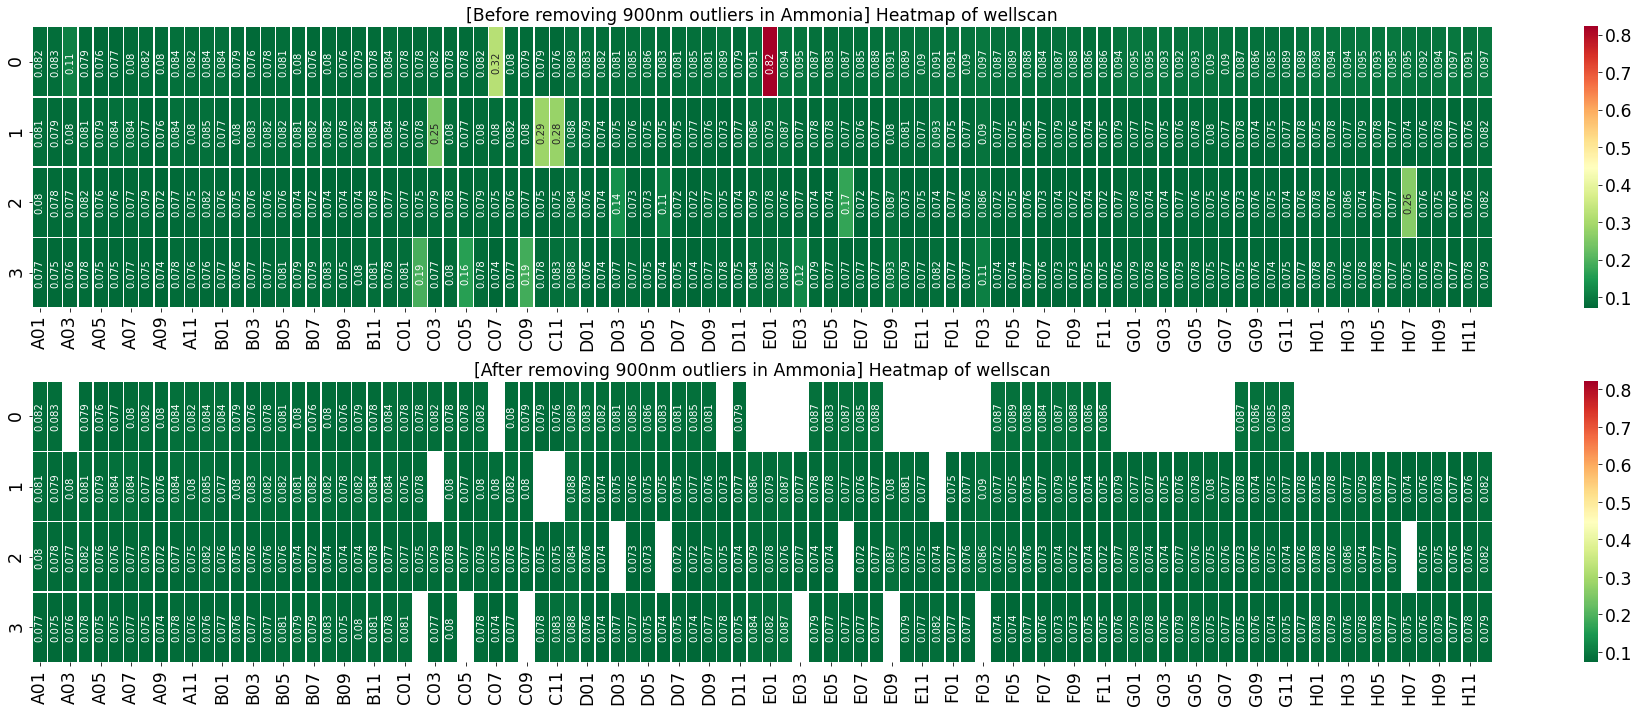

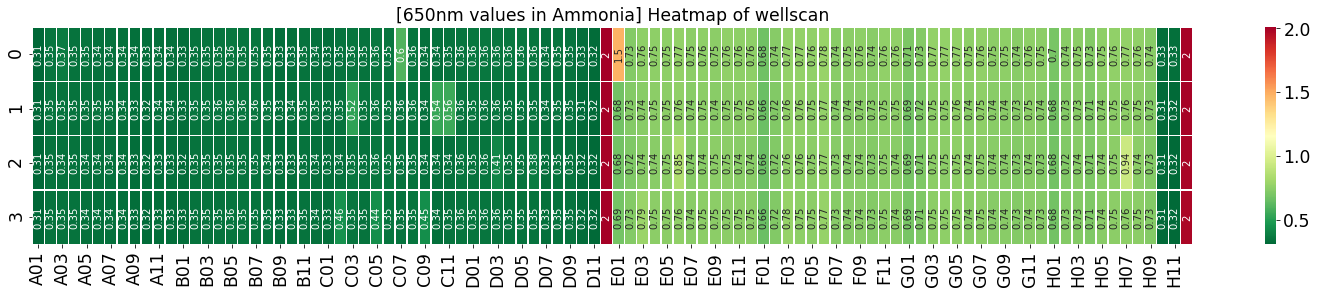

./240501_Ammonia/sample_metadata_Soil10_T4.csv
Currently using this fit:  [0.004487087370991127, 2.1418846361056683, -0.12848934521331828]
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.30655
A02    0.34995
A03    0.34550
A04    0.35095
A05    0.34555
        ...   
H08    0.74560
H09    0.72870
H10    0.31360
H11    0.31700
H12    1.99230
Name: Ammonia_OD650, Length: 96, dtype: float64
Subtracted blank value
A01   -0.01985
A02    0.02355
A03    0.01910
A04    0.02455
A05    0.01915
        ...   
H08    0.41920
H09    0.40230
H10   -0.01280
H11   -0.00940
H12    1.66590
Name: Ammonia_OD650, Length: 96, dtype: float64
Use the fit to infer Ammonia mM
A01    0.000000
A02    0.008905
A03    0.006825
A04    0.009372
A05    0.006849
         ...   
H08    0.195923
H09    0.187847
H10    0.000000
H11    0.000000
H12    0.815581
Name: Ammonia_mM, Length: 96, dtype: float64
      Nitrite_input  Nitrate_input  Ammonium

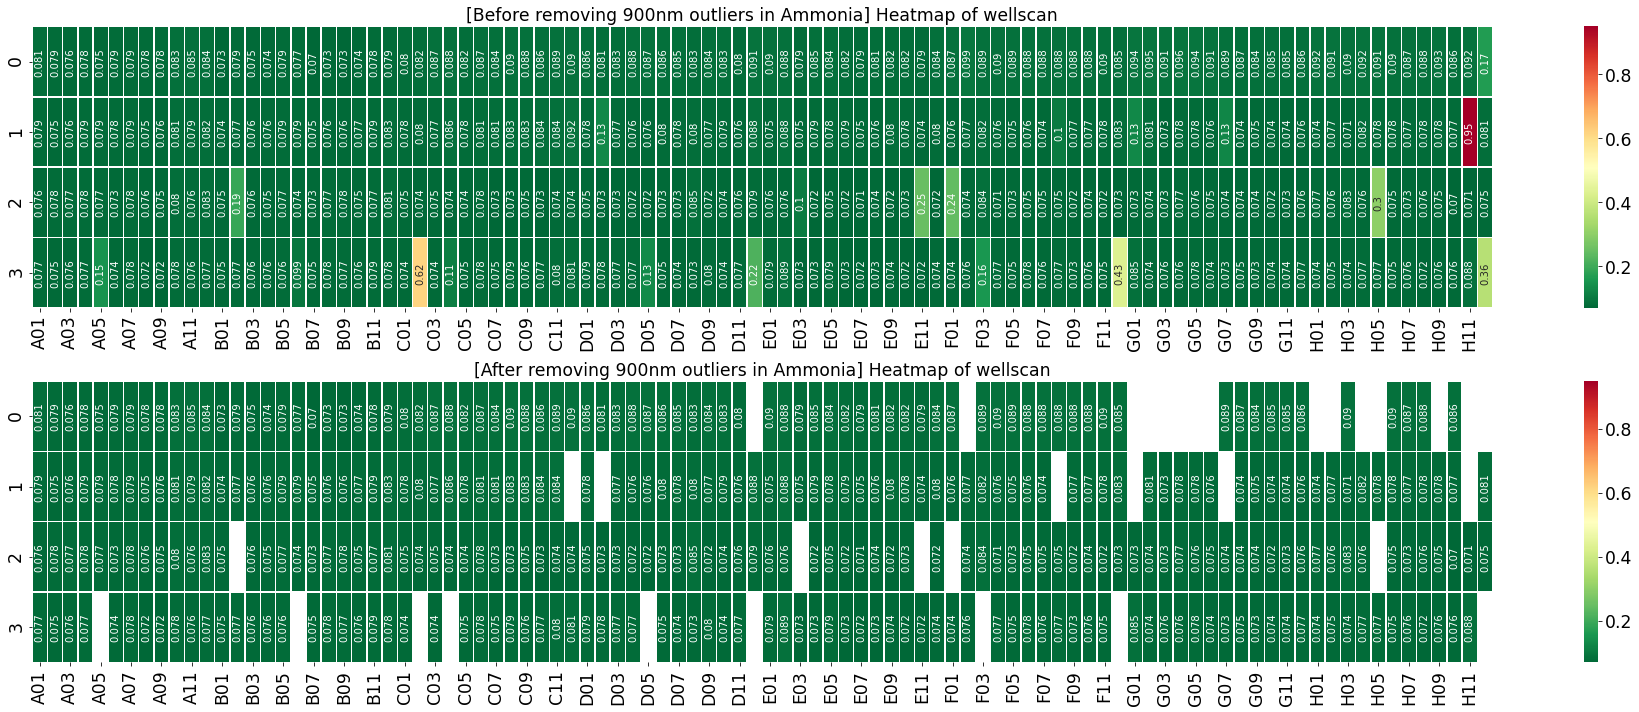

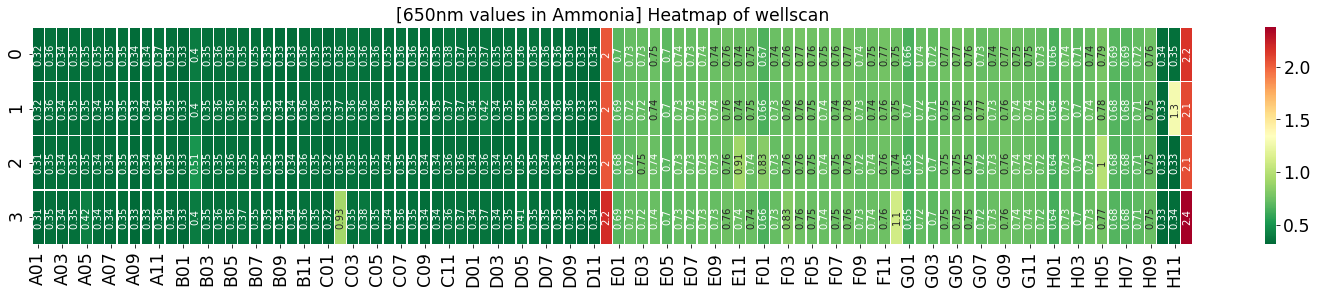

./240501_Ammonia/sample_metadata_Soil10_T5.csv
Currently using this fit:  [0.004487087370991127, 2.1418846361056683, -0.12848934521331828]
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.31565
A02    0.35395
A03    0.33835
A04    0.35025
A05    0.34980
        ...   
H08    0.70980
H09    0.74850
H10    0.33030
H11    0.33675
H12    2.07245
Name: Ammonia_OD650, Length: 96, dtype: float64
Subtracted blank value
A01   -0.01075
A02    0.02755
A03    0.01195
A04    0.02385
A05    0.02340
        ...   
H08    0.38340
H09    0.42210
H10    0.00390
H11    0.01035
H12    1.74605
Name: Ammonia_OD650, Length: 96, dtype: float64
Use the fit to infer Ammonia mM
A01    0.000000
A02    0.010775
A03    0.003485
A04    0.009045
A05    0.008835
         ...   
H08    0.178825
H09    0.197310
H10    0.000000
H11    0.002738
H12    0.857175
Name: Ammonia_mM, Length: 96, dtype: float64
      Nitrite_input  Nitrate_input  Ammonium

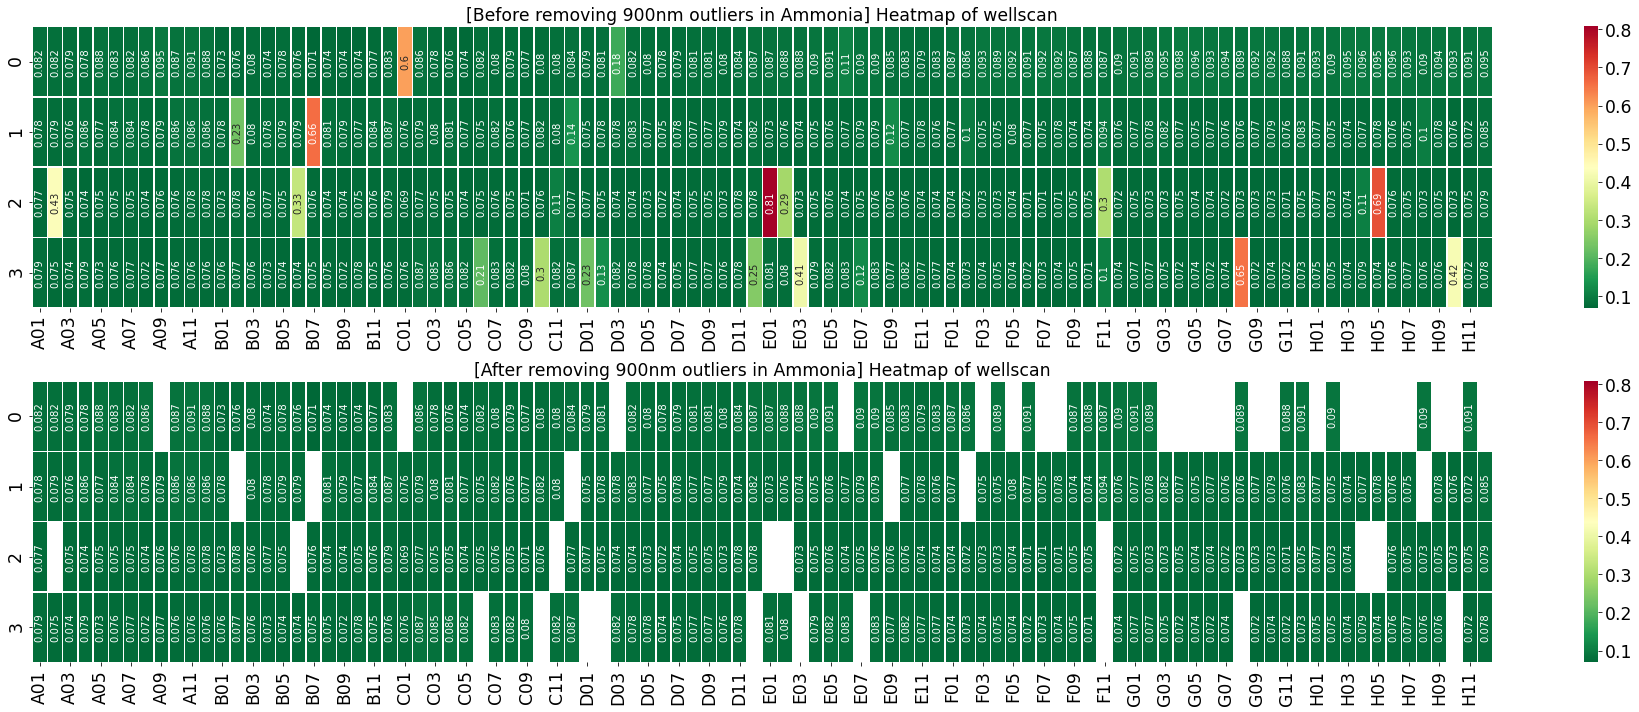

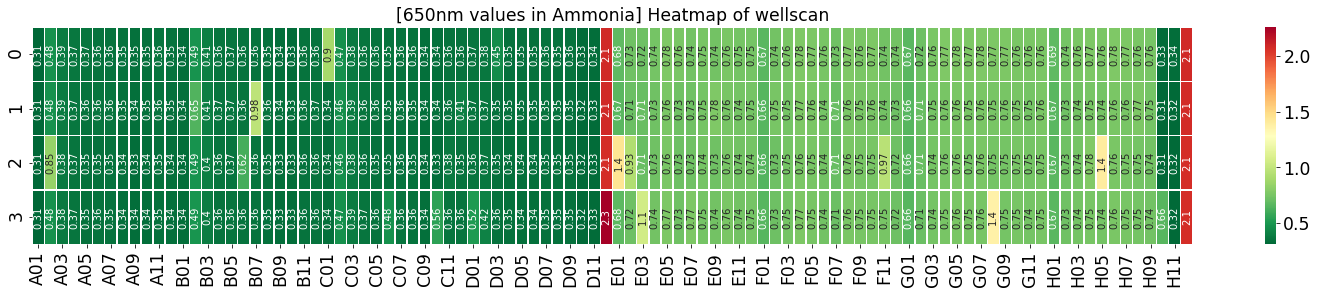

./240501_Ammonia/sample_metadata_Soil10_T6.csv
Currently using this fit:  [0.004487087370991127, 2.1418846361056683, -0.12848934521331828]
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.31300
A02    0.47880
A03    0.38450
A04    0.36780
A05    0.35475
        ...   
H08    0.74860
H09    0.74210
H10    0.31030
H11    0.32150
H12    2.07060
Name: Ammonia_OD650, Length: 96, dtype: float64
Subtracted blank value
A01   -0.01340
A02    0.15240
A03    0.05810
A04    0.04140
A05    0.02835
        ...   
H08    0.42220
H09    0.41570
H10   -0.01610
H11   -0.00490
H12    1.74420
Name: Ammonia_OD650, Length: 96, dtype: float64
Use the fit to infer Ammonia mM
A01    0.000000
A02    0.069346
A03    0.025068
A04    0.017252
A05    0.011149
         ...   
H08    0.197358
H09    0.194250
H10    0.000000
H11    0.000000
H12    0.856213
Name: Ammonia_mM, Length: 96, dtype: float64
      Nitrite_input  Nitrate_input  Ammonium

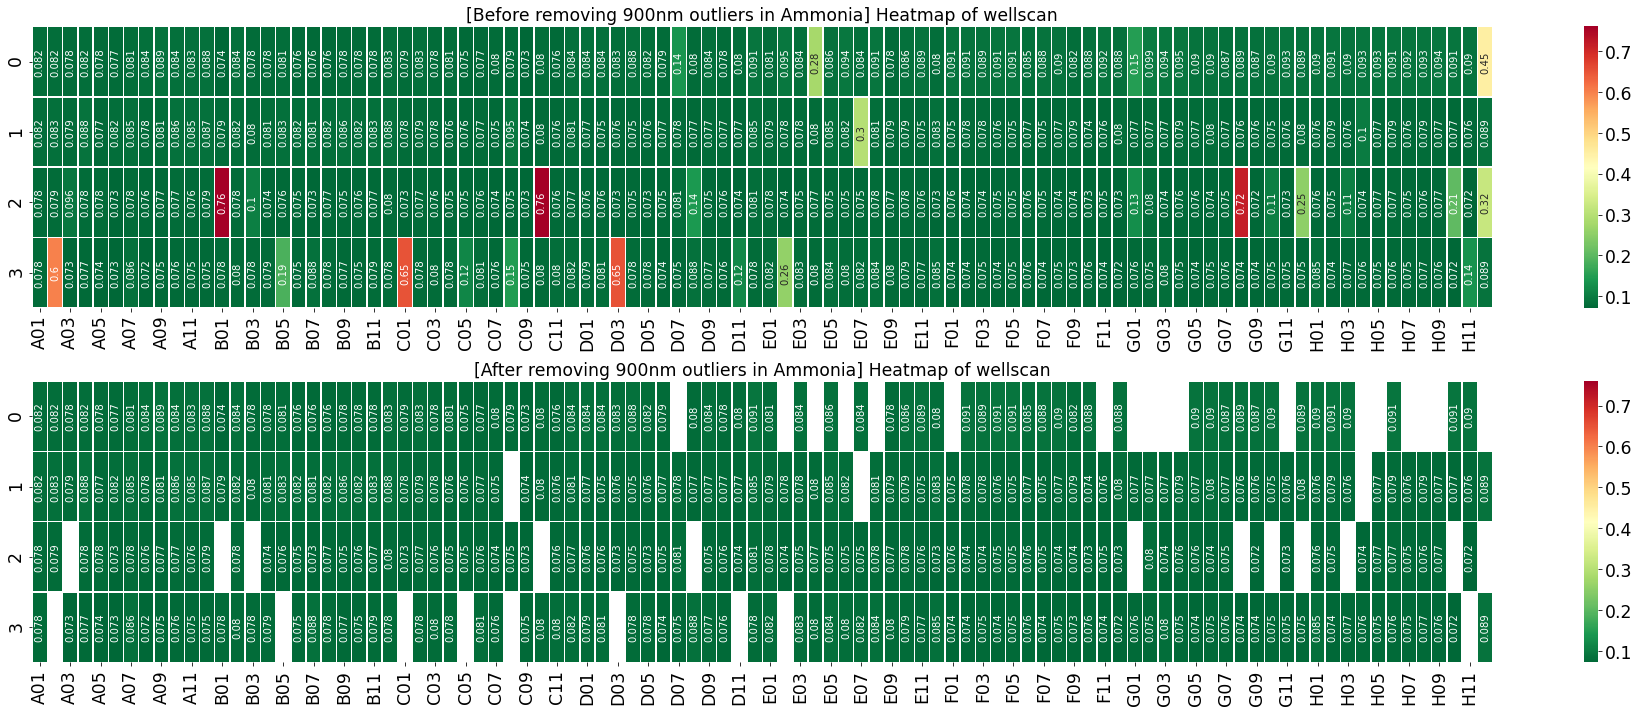

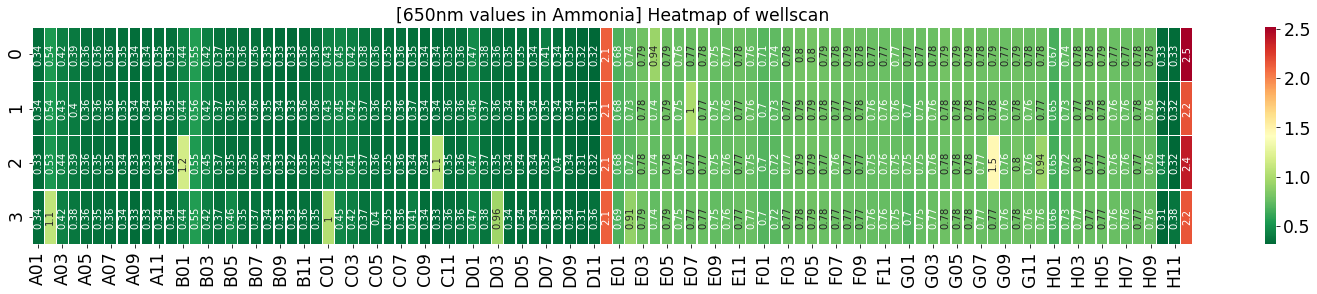

./240501_Ammonia/sample_metadata_Soil10_T7.csv
Currently using this fit:  [0.004487087370991127, 2.1418846361056683, -0.12848934521331828]
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.33710
A02    0.53690
A03    0.42250
A04    0.39075
A05    0.36100
        ...   
H08    0.77230
H09    0.76290
H10    0.31500
H11    0.31880
H12    2.16345
Name: Ammonia_OD650, Length: 96, dtype: float64
Subtracted blank value
A01    0.01070
A02    0.21050
A03    0.09610
A04    0.06435
A05    0.03460
        ...   
H08    0.44590
H09    0.43650
H10   -0.01140
H11   -0.00760
H12    1.83705
Name: Ammonia_OD650, Length: 96, dtype: float64
Use the fit to infer Ammonia mM
A01    0.002901
A02    0.096744
A03    0.042882
A04    0.027996
A05    0.014071
         ...   
H08    0.208699
H09    0.204199
H10    0.000000
H11    0.000000
H12    0.904682
Name: Ammonia_mM, Length: 96, dtype: float64
      Nitrite_input  Nitrate_input  Ammonium

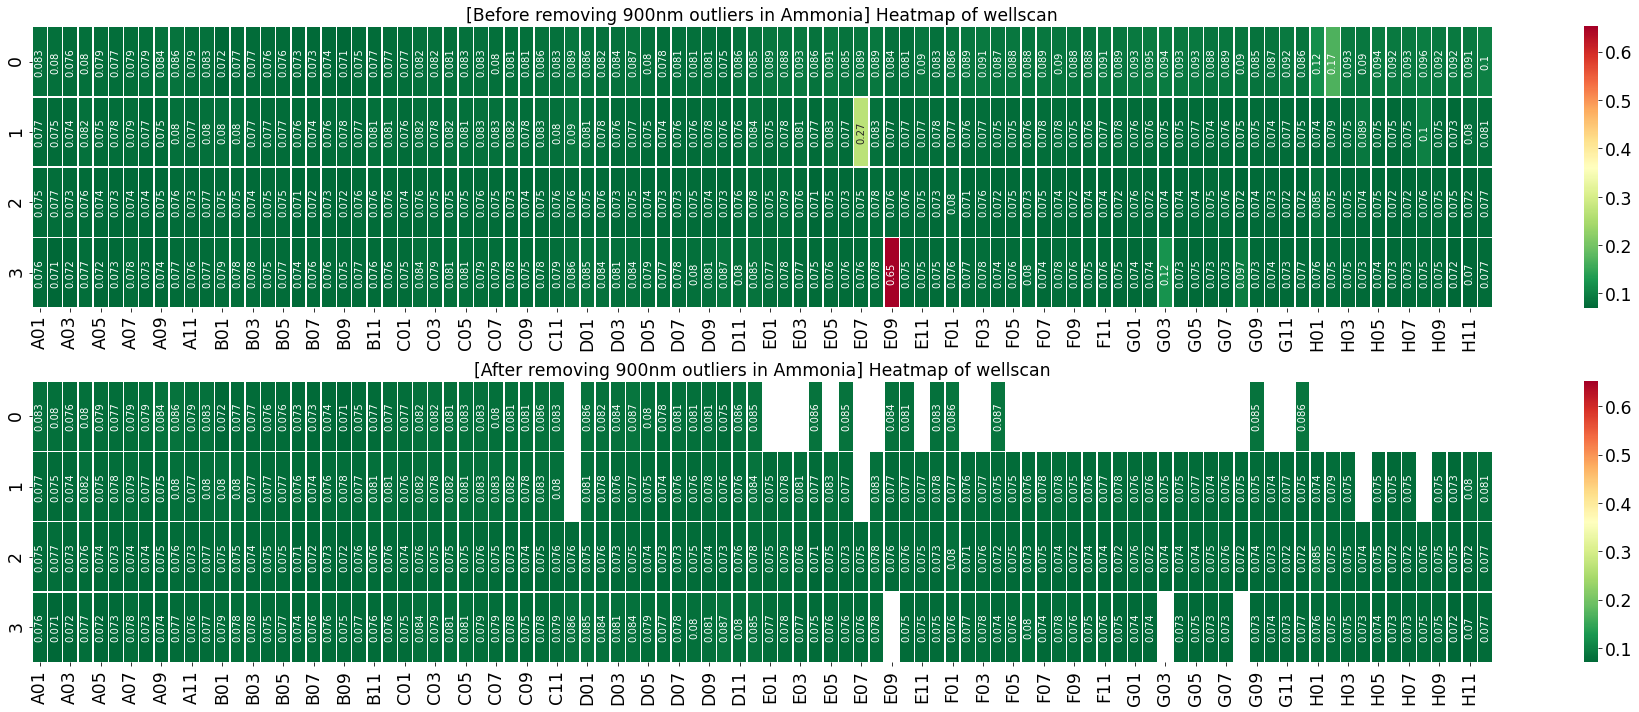

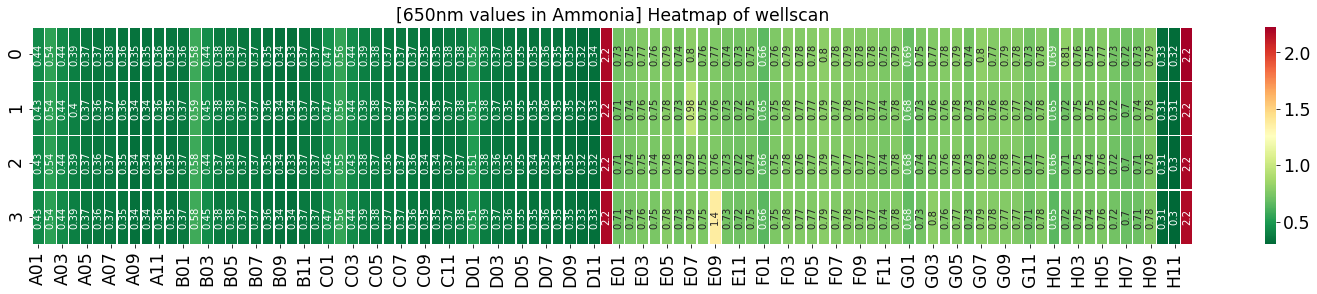

./240501_Ammonia/sample_metadata_Soil10_T8.csv
Currently using this fit:  [0.004487087370991127, 2.1418846361056683, -0.12848934521331828]
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.43185
A02    0.53935
A03    0.43885
A04    0.39380
A05    0.36895
        ...   
H08    0.71070
H09    0.77820
H10    0.30790
H11    0.30080
H12    2.19160
Name: Ammonia_OD650, Length: 96, dtype: float64
Subtracted blank value
A01    0.10545
A02    0.21295
A03    0.11245
A04    0.06740
A05    0.04255
        ...   
H08    0.38430
H09    0.45180
H10   -0.01850
H11   -0.02560
H12    1.86520
Name: Ammonia_OD650, Length: 96, dtype: float64
Use the fit to infer Ammonia mM
A01    0.047271
A02    0.097902
A03    0.050559
A04    0.029425
A05    0.017790
         ...   
H08    0.179254
H09    0.211525
H10    0.000000
H11    0.000000
H12    0.919440
Name: Ammonia_mM, Length: 96, dtype: float64
      Nitrite_input  Nitrate_input  Ammonium

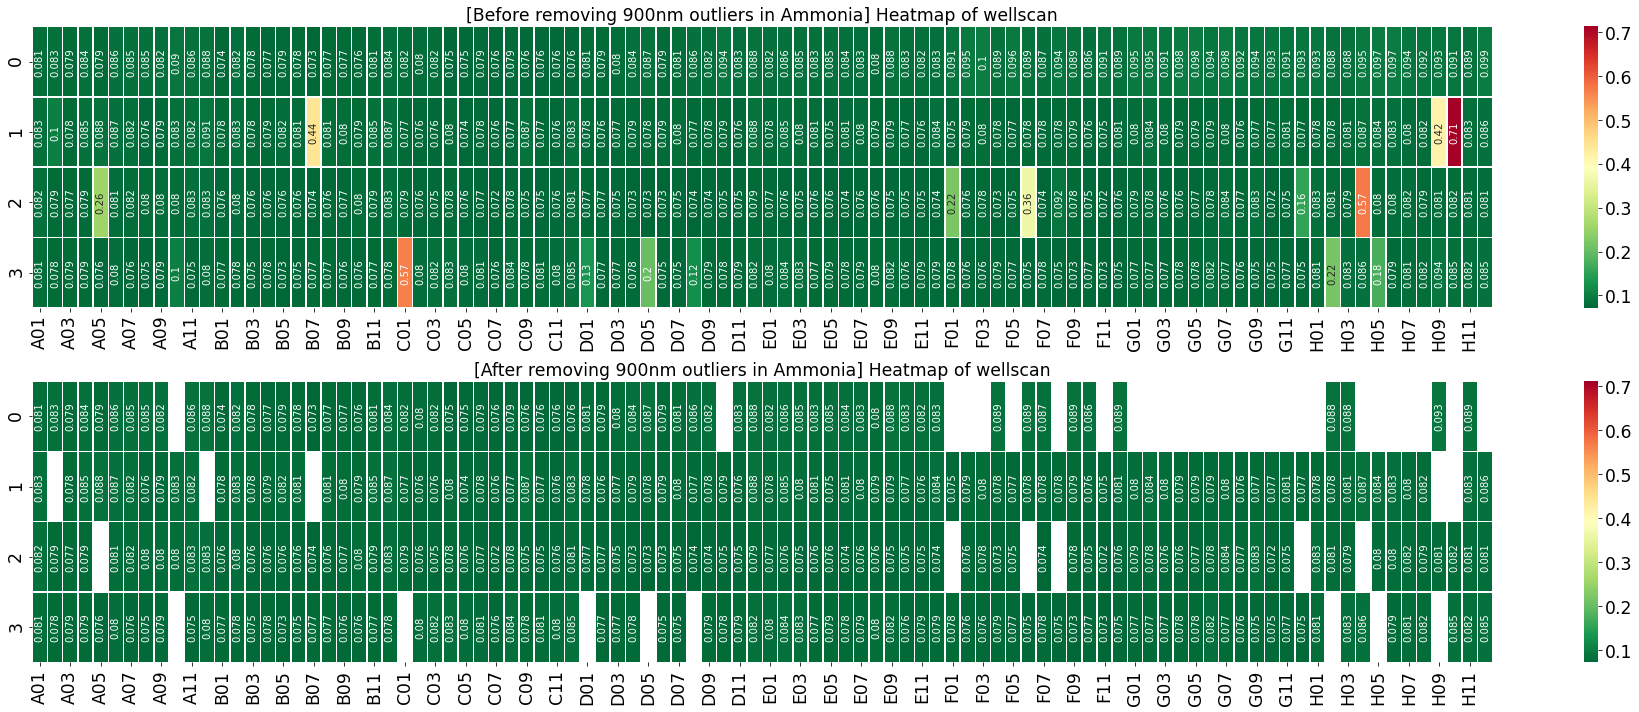

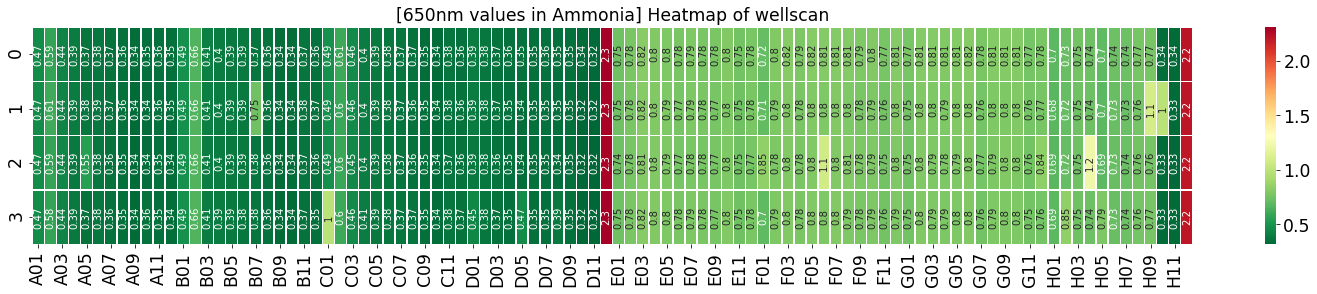

./240501_Ammonia/sample_metadata_Soil10_T9.csv
Currently using this fit:  [0.004487087370991127, 2.1418846361056683, -0.12848934521331828]
Before subtracting blank value
returns true for elements more than 1 interquartile ranges above the upper quartile
A01    0.46845
A02    0.58550
A03    0.43960
A04    0.39240
A05    0.37230
        ...   
H08    0.76330
H09    0.76705
H10    0.33285
H11    0.33290
H12    2.21690
Name: Ammonia_OD650, Length: 96, dtype: float64
Subtracted blank value
A01    0.14205
A02    0.25910
A03    0.11320
A04    0.06600
A05    0.04590
        ...   
H08    0.43690
H09    0.44065
H10    0.00645
H11    0.00650
H12    1.89050
Name: Ammonia_OD650, Length: 96, dtype: float64
Use the fit to infer Ammonia mM
A01    0.064475
A02    0.119733
A03    0.050911
A04    0.028769
A05    0.019357
         ...   
H08    0.204390
H09    0.206185
H10    0.000916
H11    0.000940
H12    0.932728
Name: Ammonia_mM, Length: 96, dtype: float64
      Nitrite_input  Nitrate_input  Ammonium

In [5]:
# Loop through sample names
for i in l_soil:
    for j in l_timepoint:
        sample_name = i+"_"+j
        print(sample_name)
        plate1_meta_fn = "./240501_Ammonia/sample_metadata_"+sample_name+".csv"
        print(plate1_meta_fn)
        plate1_am_fn = None
        print(plate1_am_fn)
        plate1_am_absorb_fn = glob.glob("./240501_Ammonia/*"+sample_name+"_*Ammonia_SCAN_650*")[0]
        print(plate1_am_absorb_fn)
        plate1_am_900_fn = glob.glob("./240501_Ammonia/*"+sample_name+"_*Ammonia_SCAN_900*")[0]
        print(plate1_am_900_fn)
        
        am.get_concentration_xlsx(excel_output = "./240501_Ammonia/Output/240501_Ammonia_"+sample_name+".xlsx",
                                  ammonia_blank = ammonia_blank, fit = b_fit, meta_fn = plate1_meta_fn, wavelength = "650",
                                  data_fn=plate1_am_fn, data_absorb_fn=plate1_am_absorb_fn, data_900_fn=plate1_am_900_fn)
        
        print("--------------------------------------------------------------------------------------------------------------")

